# v7 — reverse-engineer test onset (~161) and detect in [160, 200-ish]

v6 scored **whole runs**. Here we use a fact about the **test** file: a disturbance is injected at **8 h**, and samples are **3 min** apart, so the first faulty sample should be **161**. Until then, a test run labelled `faulty` is still physically normal.

This notebook **does not trust that number**. It measures it on the v6 frames (`df1` test-normal, `df2` test-faulty), then builds detectors that only look at a short post-onset window.

## Hypotheses

1. **Prefix is shared.** On test data, z-scores of samples `1…160` vs that run’s own prefix look the same for IDV(0) and IDV(1–20). You cannot call a run faulty before 161 without guessing.
2. **The step is at 161, the *evidence* arrives later.** Easy IDVs (1, 2, 4–7, 11, 12, 14) jump immediately. Slow / weak IDVs (3, 9, 15, then 10, 13, 16, 19, 20) need **20–80 extra samples** before they leave the healthy noise band. That is why the useful window is **`[161, ~200–250]`**, not a single tick.
3. **Healthy runs also wander.** If you watch until sample 960, FPR explodes (random 6–8σ ticks). If you only watch `[161, W]`, FPR is the chance a healthy run has a tail event *in that short interval*. Smaller `W` → lower FPR, lower TPR.
4. **IDV 3 / 9 / 15 almost do not move in 40 samples.** No window detector will get high TPR on those three without wrecking FPR. Budget TPR against the other 17 IDVs, then decide.
5. **Freeze/amplitude are the wrong tool for this window.** v5 freeze needs a long stuck streak (extra 5–14 diffs). Forty samples is not enough. The onset window is a **level-shift / z-score** problem.
6. **The right baseline is this run’s own `[1, 160]`.** Both classes are healthy there, so `μ, σ` from the prefix is a fair, causal, label-free envelope. Then score only `t ≥ 161`.

Eval set: **500 test-normal + 1,000 test-faulty** (50 per IDV). Train-normal is a side FPR check (no 8 h injection, but `[161, W]` still exists on 500-sample train runs).


In [9]:
from __future__ import annotations

import logging
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

log = logging.getLogger("v7_onset")
if not log.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(asctime)s  %(levelname)-7s  %(message)s", datefmt="%H:%M:%S"))
    log.addHandler(handler)
    log.setLevel(logging.INFO)
    log.propagate = False

CACHE_NORMAL = Path("v6_df1_normal_1000runs.csv")
CACHE_FAULTY = Path("v6_df2_faulty_50per_idv.csv")
V6_ALARMS = Path("v6_eval_alarms.csv")
SCORE_CACHE = Path("v7_onset_scores.csv")
CURVE_CACHE = Path("v7_onset_zmax_curves.npz")
FAMILY_CACHE = Path("v7_family_scores.csv")
EXTRA_CACHE = Path("v7_extra_scores.csv")

ONSET = 161
PRE_LO, PRE_HI = 1, 160
POST_LO = 161
POST_ENDS = (180, 200, 220, 250, 300)
DEFAULT_W = 220
HARD_IDV = {3, 9, 15}
YELLOW, RED, BLUE = "#E0B000", "#C0392B", "#2C3E50"

df1 = pd.read_csv(CACHE_NORMAL)
df2 = pd.read_csv(CACHE_FAULTY)
SENSOR_COLS = [c for c in df1.columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]
MEAS_COLS = [c for c in SENSOR_COLS if str(c).startswith("xmeas_")]

test_normal = df1.loc[df1["source"].astype(str).eq("test")].copy()
test_faulty = df2.copy()
train_normal = df1.loc[df1["source"].astype(str).eq("train")].copy()

def n_runs(df: pd.DataFrame) -> int:
    return df.groupby(["source", "faultNumber", "simulationRun"], observed=True).ngroups

log.info("test normal  %s runs  %s rows", n_runs(test_normal), f"{len(test_normal):,}")
log.info("test faulty  %s runs  %s rows  (50 / IDV)", n_runs(test_faulty), f"{len(test_faulty):,}")
log.info("train normal %s runs  (FPR side check)", n_runs(train_normal))
log.info("onset        sample %s  prefix %s–%s  default window [%s, %s]", ONSET, PRE_LO, PRE_HI, POST_LO, DEFAULT_W)


19:55:50  INFO     test normal  500 runs  480,000 rows
19:55:51  INFO     test faulty  1000 runs  960,000 rows  (50 / IDV)
19:55:51  INFO     train normal 500 runs  (FPR side check)
19:55:51  INFO     onset        sample 161  prefix 1–160  default window [161, 220]


## 1. Reverse-engineer the 161 step

For every test run, fit `μ, σ` on samples **1–160 of that run**, then plot `zmax(t) = max_sensor |(x_t − μ) / σ|`.

If hypothesis 1–2 are right: the **median** curve for faulty sits on top of normal through sample 160, peels off at 161, and keeps rising through ~200. Normal stays flat. Easy IDVs peel off hard; 3 / 9 / 15 barely move.


19:55:51  INFO     curve cache v7_onset_zmax_curves.npz


median zmax (prefix baseline) at selected samples
     t    normal    faulty  faulty p90
     1      1.79      1.78        2.41
    80      2.32      2.31        2.91
   150      2.40      2.39        3.01
   158      2.50      2.52        3.08
   160      2.55      2.55        3.18
   161      2.64      2.93       10.33
   165      2.73      3.19       10.95
   180      2.81      5.06       19.87
   200      2.89      6.78       22.25
   220      2.94      7.88       27.66
   250      2.84     10.54       36.15
   400      2.81     10.99       45.51
   800      2.78     10.52       83.11


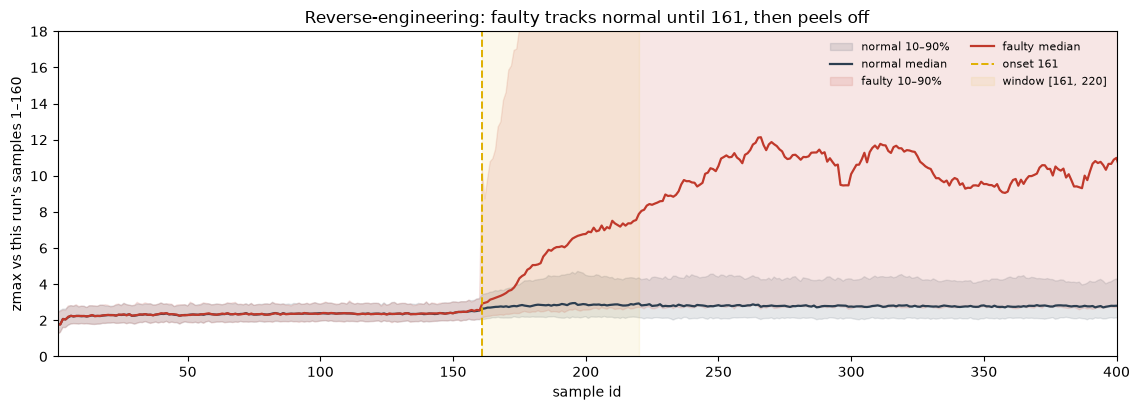

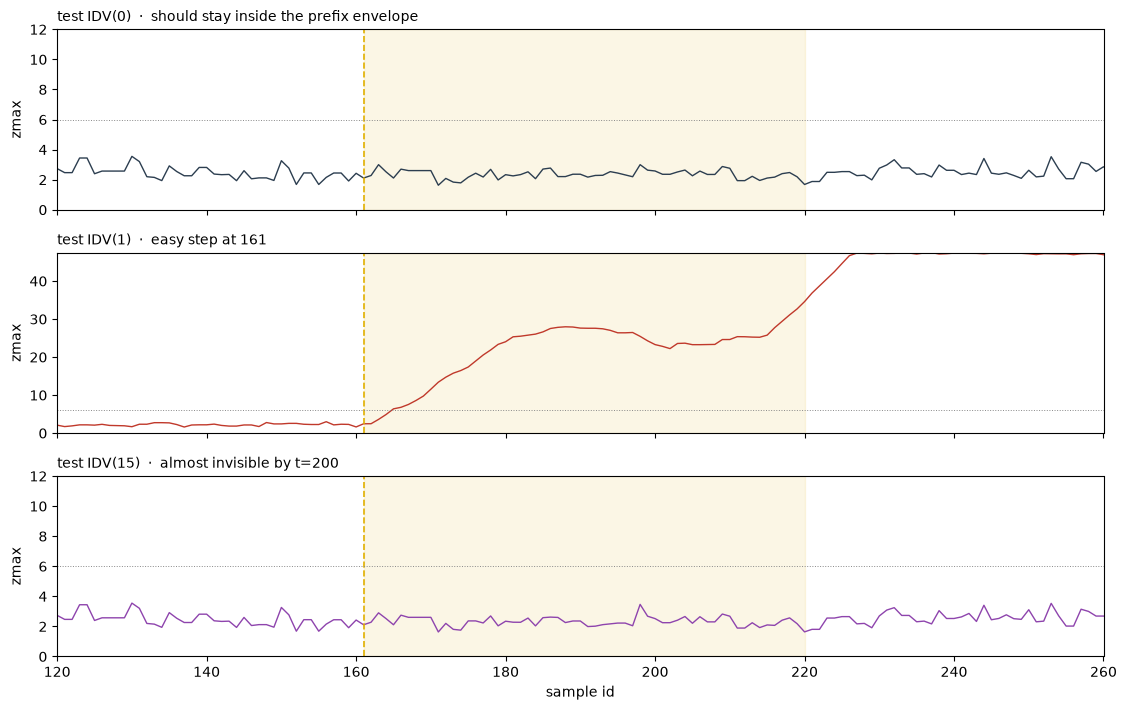

In [10]:
def prefix_zmax_series(frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """zmax(t) using μ,σ from samples 1–160 of this run. Returns (zmax aligned to sample 1..T, samples)."""
    g = frame.sort_values("sample")
    X = g[SENSOR_COLS].to_numpy(np.float64)
    s = g["sample"].to_numpy(np.int16)
    pre = X[(s >= PRE_LO) & (s <= PRE_HI)]
    mu = pre.mean(axis=0)
    sd = np.maximum(pre.std(axis=0, ddof=1), 1e-12)
    zmax = np.nanmax(np.abs(X - mu) / sd, axis=1)
    T = int(s.max())
    aligned = np.full(T, np.nan, dtype=np.float64)
    aligned[s - 1] = zmax
    return aligned, s


def median_curves(df: pd.DataFrame, tmax: int = 960) -> dict[str, np.ndarray]:
    acc = []
    for _, g in df.groupby(["source", "faultNumber", "simulationRun"], sort=False, observed=True):
        z, _ = prefix_zmax_series(g)
        row = np.full(tmax, np.nan)
        row[: min(len(z), tmax)] = z[:tmax]
        acc.append(row)
    A = np.vstack(acc)
    with np.errstate(all="ignore"):
        return {
            "n": A.shape[0],
            "median": np.nanmedian(A, axis=0),
            "p90": np.nanpercentile(A, 90, axis=0),
            "p10": np.nanpercentile(A, 10, axis=0),
        }


if CURVE_CACHE.exists():
    blob = np.load(CURVE_CACHE)
    n_curve = {k: blob[f"n_{k}"] for k in ("median", "p90", "p10")}
    f_curve = {k: blob[f"f_{k}"] for k in ("median", "p90", "p10")}
    log.info("curve cache %s", CURVE_CACHE.name)
else:
    t0 = time.time()
    n_curve = median_curves(test_normal)
    f_curve = median_curves(test_faulty)
    np.savez(
        CURVE_CACHE,
        n_median=n_curve["median"], n_p90=n_curve["p90"], n_p10=n_curve["p10"],
        f_median=f_curve["median"], f_p90=f_curve["p90"], f_p10=f_curve["p10"],
    )
    log.info("curve write %s  %.1fs", CURVE_CACHE.name, time.time() - t0)

t = np.arange(1, 961)
print("median zmax (prefix baseline) at selected samples")
print(f"{'t':>6}  {'normal':>8}  {'faulty':>8}  {'faulty p90':>10}")
for tt in (1, 80, 150, 158, 160, 161, 165, 180, 200, 220, 250, 400, 800):
    print(f"{tt:6d}  {n_curve['median'][tt-1]:8.2f}  {f_curve['median'][tt-1]:8.2f}  {f_curve['p90'][tt-1]:10.2f}")

fig, ax = plt.subplots(figsize=(11.5, 4.2))
ax.fill_between(t, n_curve["p10"], n_curve["p90"], color=BLUE, alpha=0.12, label="normal 10–90%")
ax.plot(t, n_curve["median"], color=BLUE, lw=1.6, label="normal median")
ax.fill_between(t, f_curve["p10"], f_curve["p90"], color=RED, alpha=0.12, label="faulty 10–90%")
ax.plot(t, f_curve["median"], color=RED, lw=1.6, label="faulty median")
ax.axvline(ONSET, color=YELLOW, lw=1.4, ls="--", label=f"onset {ONSET}")
ax.axvspan(161, DEFAULT_W, color=YELLOW, alpha=0.08, label=f"window [161, {DEFAULT_W}]")
ax.set_xlim(1, 400)
ax.set_ylim(0, 18)
ax.set_xlabel("sample id")
ax.set_ylabel("zmax vs this run's samples 1–160")
ax.set_title("Reverse-engineering: faulty tracks normal until 161, then peels off")
ax.legend(frameon=False, ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

# One easy / one hard trace.
def pick_run(df: pd.DataFrame, fault: int, run: int | None = None) -> pd.DataFrame:
    sub = df.loc[df["faultNumber"].astype(int).eq(fault)]
    rn = int(run if run is not None else sub["simulationRun"].iloc[0])
    return sub.loc[sub["simulationRun"].astype(int).eq(rn)]

fig, axes = plt.subplots(3, 1, figsize=(11.5, 7.2), sharex=True)
examples = [
    (pick_run(test_normal, 0), BLUE, "test IDV(0)  ·  should stay inside the prefix envelope"),
    (pick_run(test_faulty, 1), RED, "test IDV(1)  ·  easy step at 161"),
    (pick_run(test_faulty, 15), "#8E44AD", "test IDV(15)  ·  almost invisible by t=200"),
]
for ax, (g, color, title) in zip(axes, examples):
    z, s = prefix_zmax_series(g)
    ax.plot(np.arange(1, len(z) + 1), z, color=color, lw=1.0)
    ax.axvline(ONSET, color=YELLOW, lw=1.2, ls="--")
    ax.axvspan(161, DEFAULT_W, color=YELLOW, alpha=0.10)
    ax.axhline(6, color="#888", lw=0.7, ls=":")
    ax.set_xlim(120, 260)
    ax.set_ylim(0, max(12, np.nanpercentile(z[120:260], 99)))
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("zmax")
axes[-1].set_xlabel("sample id")
fig.tight_layout()
plt.show()


## 2. Methods (all causal, no CSV labels)

Shared protocol: `μ, σ` from samples **1–160 of this run**. Decision uses only `t ∈ [161, W]`. A run is **faulty if the method fires at least once** in that window, else normal.

| id | method | idea | why it should help |
|---|---|---|---|
| **A. prefix_zmax** | `max_{t∈[161,W]} zmax_t` | Did any tick in the onset window leave the prefix envelope? | Direct reading of hypothesis 2. Threshold 7–8 keeps FPR tiny. |
| **B. prefix_persist** | k consecutive zmax ≥ 4 inside the window | Same as v6 `zscore_4sd_self`, but **gated** to `[161, W]` | Isolated healthy spikes before 160 / after W no longer count. |
| **C. prefix_spe** | PCA on the prefix (90% variance), SPE = `\|z − ẑ\|^2` on the window; score = max SPE / 99th percentile of prefix SPE | A fault can sit inside every sensor’s `[min, max]` and still be a wrong *combination* | Complements zmax on IDVs that rotate the plant rather than slam one tag. |
| **D. v6 whole-run** | v5_combined / zscore k=6 on **all** samples (from `v6_eval_alarms.csv`) | Control: what we had without using 161 | Shows how much FPR was coming from watching the wrong time. |
| **E. A ∨ D** | `prefix_zmax≥8` on `[161, W]` **or** v6 `zscore_k6` anywhere | Frozen prefix envelope for the onset step, expanding 6-tick z for the rest of the run | The two takeaways from v7 / v6; §4 measures whether they actually add TP. |

**What we are *not* doing in the short window:** v5 freeze / amplitude. Those need long streaks or a growing envelope; 40–90 ticks after onset is the wrong timescale.

**Choosing `W`.** `[161, 180]` is too tight (easy IDVs only). `[161, 960]` is v6 again. **`W = 220` (~3 h after onset)** is the default “200-ish” window. The sweep also reports 180 / 200 / 250 / 300.


In [11]:
def consecutive_k(hits: np.ndarray, k: int) -> bool:
    streak = 0
    for v in np.asarray(hits, dtype=bool):
        streak = streak + 1 if v else 0
        if streak >= k:
            return True
    return False


def score_run(frame: pd.DataFrame, w: int = DEFAULT_W) -> dict:
    g = frame.sort_values("sample")
    X = g[SENSOR_COLS].to_numpy(np.float64)
    s = g["sample"].to_numpy(np.int16)
    pre_m = (s >= PRE_LO) & (s <= PRE_HI)
    win_m = (s >= POST_LO) & (s <= w)
    pre, post = X[pre_m], X[win_m]
    src = str(g["source"].iloc[0])
    fn = int(g["faultNumber"].iloc[0])
    rn = int(g["simulationRun"].iloc[0])
    status = str(g["fault_status"].iloc[0])
    rec = {"source": src, "IDV": fn, "run": rn, "csv_status": status, "W": w, "n_pre": int(len(pre)), "n_win": int(len(post))}
    if len(pre) < 80 or len(post) < 8:
        rec.update(zmax=np.nan, persist_k2=0, persist_k3=0, spe_ratio=np.nan)
        return rec

    mu = pre.mean(axis=0)
    sd = np.maximum(pre.std(axis=0, ddof=1), 1e-12)
    zmax_all = np.nanmax(np.abs(X - mu) / sd, axis=1)
    z_win = zmax_all[win_m]
    rec["zmax"] = float(np.nanmax(z_win))
    rec["persist_k2"] = int(consecutive_k(z_win >= 4.0, 2))
    rec["persist_k3"] = int(consecutive_k(z_win >= 4.0, 3))
    rec["persist_k4_thr5"] = int(consecutive_k(z_win >= 5.0, 4))

    scaler = StandardScaler()
    Zpre = scaler.fit_transform(pre)
    pca = PCA(n_components=0.90, svd_solver="full")
    pca.fit(Zpre)

    def spe(Xp: np.ndarray) -> np.ndarray:
        Z = scaler.transform(Xp)
        recov = pca.inverse_transform(pca.transform(Z))
        return np.sum((Z - recov) ** 2, axis=1)

    spe_pre = spe(pre)
    spe_post = spe(post)
    rec["spe_ratio"] = float(spe_post.max() / max(float(np.quantile(spe_pre, 0.99)), 1e-12))
    return rec


def score_split(df: pd.DataFrame, w: int) -> pd.DataFrame:
    rows = [score_run(g, w) for _, g in df.groupby(["source", "faultNumber", "simulationRun"], sort=False, observed=True)]
    return pd.DataFrame(rows)


def load_or_score() -> pd.DataFrame:
    if SCORE_CACHE.exists():
        out = pd.read_csv(SCORE_CACHE)
        log.info("score cache %s  rows=%s", SCORE_CACHE.name, f"{len(out):,}")
        return out
    parts = []
    t0 = time.time()
    for w in POST_ENDS:
        for name, df in (("test_normal", test_normal), ("test_faulty", test_faulty), ("train_normal", train_normal)):
            part = score_split(df, w)
            part["block"] = name
            parts.append(part)
            log.info("scored      W=%s  %s  runs=%s  %.1fs", w, name, len(part), time.time() - t0)
    out = pd.concat(parts, ignore_index=True)
    out.to_csv(SCORE_CACHE, index=False)
    log.info("score write %s  rows=%s", SCORE_CACHE.name, f"{len(out):,}")
    return out


scores = load_or_score()
print(scores.head())


19:55:51  INFO     score cache v7_onset_scores.csv  rows=10,000


  source  IDV  run csv_status    W  n_pre  n_win      zmax  persist_k2  persist_k3  persist_k4_thr5  spe_ratio        block
0   test    0    1     normal  180    160     20  2.998939           0           0                0   2.038909  test_normal
1   test    0    2     normal  180    160     20  3.520554           0           0                0   2.681141  test_normal
2   test    0    3     normal  180    160     20  3.835813           0           0                0   1.637421  test_normal
3   test    0    4     normal  180    160     20  4.419821           1           1                0   2.677307  test_normal
4   test    0    5     normal  180    160     20  3.460061           0           0                0   2.490062  test_normal


## 3. TPR / FPR

Same rule as v6: **any fire → predicted faulty**. TPR on 1,000 test-faulty runs, FPR on 500 test-normal runs. Youden = TPR − FPR.

Also: TPR on the 17 “easy” IDVs vs IDV 3/9/15, and FPR on train-normal as a sanity check.


Default window W=220. Full sweep included.


,n_faulty,n_normal,TPR,FPR,Youden,TP,FN,FP,TN,method,W,TPR_easy,TPR_hard,FPR_train
16,1000,500,0.656,0.014,0.642,656,344,7,493,A prefix_zmax≥8,220,0.768,0.020,0.024
15,1000,500,0.685,0.044,0.641,685,315,22,478,A prefix_zmax≥7,220,0.796,0.053,0.038
19,1000,500,0.710,0.074,0.636,710,290,37,463,C PCA SPE ≥5×,220,0.824,0.067,0.042
20,1000,500,0.718,0.082,0.636,718,282,41,459,A∨C zmax≥8 or SPE≥5×,220,0.831,0.080,—
36,1000,500,0.715,0.088,0.627,715,285,44,456,v6 zscore_4sd_self k=6 (all t),—,—,—,—
14,1000,500,0.726,0.106,0.620,726,274,53,447,A prefix_zmax≥6,220,0.832,0.127,0.074
18,1000,500,0.836,0.338,0.498,836,164,169,331,B persist 3× z≥4,220,0.921,0.353,—
17,1000,500,0.865,0.418,0.447,865,135,209,291,B persist 2× z≥4,220,0.940,0.440,—
35,1000,500,0.788,0.492,0.296,788,212,246,254,v6 v5_combined (all t),—,—,—,—



Window length sweep — prefix_zmax≥8  (the high-precision setting)


,W,TPR,FPR,Youden,TPR_easy,TPR_hard,FPR_train,TP,FN,FP,TN
2,180.000000,0.425,0.000,0.425,0.500,0.000,0.006,425,575,0,500
9,200.000000,0.577,0.006,0.571,0.676,0.013,0.016,577,423,3,497
16,220.000000,0.656,0.014,0.642,0.768,0.020,0.024,656,344,7,493
23,250.000000,0.730,0.034,0.696,0.853,0.033,0.032,730,270,17,483
30,300.000000,0.758,0.044,0.714,0.886,0.033,0.050,758,242,22,478



Per IDV  (IDV 0 column is FPR on 500 test-normal runs)   W=220


,IDV,runs,med_zmax,TPR_z≥7,TPR_z≥8,TPR_persist3,TPR_SPE≥5
20,0,500,4.0,0.04,0.01,0.34,0.07
0,1,50,28.3,1.00,1.00,1.00,1.00
1,2,50,24.8,1.00,1.00,1.00,1.00
2,3,50,4.2,0.08,0.04,0.44,0.08
3,4,50,11.0,1.00,1.00,1.00,0.96
4,5,50,13.3,1.00,0.98,1.00,1.00
5,6,50,33.7,1.00,1.00,1.00,1.00
6,7,50,25.7,1.00,1.00,1.00,1.00
7,8,50,14.6,0.94,0.92,1.00,1.00
8,9,50,4.0,0.06,0.00,0.34,0.10


/var/folders/hw/zh08vgx16815gz89lgw4z6qw0000gn/T/ipykernel_2978/3736806920.py:129: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(sub["W"], sub["TPR"], "o-", color=BLUE, ls=ls, label=f"TPR  z≥{thr}")
/var/folders/hw/zh08vgx16815gz89lgw4z6qw0000gn/T/ipykernel_2978/3736806920.py:130: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(sub["W"], sub["FPR"], "s-", color=RED, ls=ls, label=f"FPR  z≥{thr}")
/var/folders/hw/zh08vgx16815gz89lgw4z6qw0000gn/T/ipykernel_2978/3736806920.py:129: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(sub["W"], sub["TPR"], "o-", color=BLUE, ls=ls, label=f"TPR  z≥{thr}")
/var/

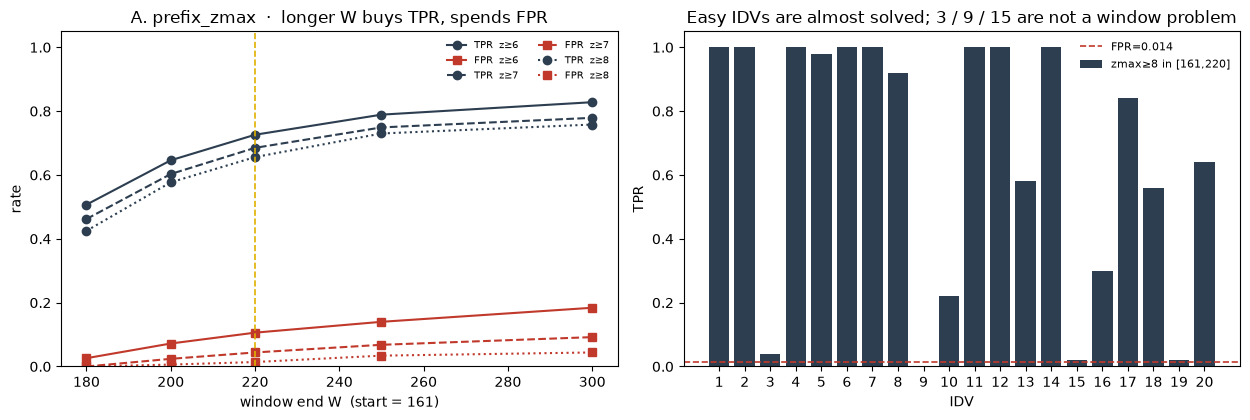

best Youden among prefix_zmax settings: A prefix_zmax≥8  W=300.0  TPR=0.758  FPR=0.044  Youden=0.714  easy=0.886  hard=0.033
recommended default: prefix_zmax≥8 on [161, 220]  — high precision, honest about IDV 3/9/15. Stretch W to 250–300 if you want more TPR.


In [12]:
def rates_from_pred(y: np.ndarray, yhat: np.ndarray) -> dict:
    y = np.asarray(y, dtype=bool)
    yhat = np.asarray(yhat, dtype=bool)
    tp = int((y & yhat).sum())
    fn = int((y & ~yhat).sum())
    fp = int((~y & yhat).sum())
    tn = int((~y & ~yhat).sum())
    n_pos, n_neg = tp + fn, fp + tn
    tpr = tp / n_pos if n_pos else np.nan
    fpr = fp / n_neg if n_neg else np.nan
    return {
        "n_faulty": n_pos, "n_normal": n_neg,
        "TPR": tpr, "FPR": fpr,
        "Youden": (tpr - fpr) if np.isfinite(tpr) and np.isfinite(fpr) else np.nan,
        "TP": tp, "FN": fn, "FP": fp, "TN": tn,
    }


def test_blocks(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    n = frame.loc[frame["block"].eq("test_normal")]
    f = frame.loc[frame["block"].eq("test_faulty")]
    return n, f


rows = []
for w, block in scores.groupby("W", sort=True):
    n, f = test_blocks(block)
    both = pd.concat([n, f], ignore_index=True)
    y = both["csv_status"].astype(str).eq("faulty").to_numpy()
    hard = f["IDV"].astype(int).isin(HARD_IDV)
    tn = block.loc[block["block"].eq("train_normal")]
    for name, pred_n, pred_f in [
        ("A prefix_zmax≥6", n["zmax"] >= 6, f["zmax"] >= 6),
        ("A prefix_zmax≥7", n["zmax"] >= 7, f["zmax"] >= 7),
        ("A prefix_zmax≥8", n["zmax"] >= 8, f["zmax"] >= 8),
        ("B persist 2× z≥4", n["persist_k2"].eq(1), f["persist_k2"].eq(1)),
        ("B persist 3× z≥4", n["persist_k3"].eq(1), f["persist_k3"].eq(1)),
        ("C PCA SPE ≥5×", n["spe_ratio"] >= 5, f["spe_ratio"] >= 5),
        ("A∨C zmax≥8 or SPE≥5×", (n["zmax"] >= 8) | (n["spe_ratio"] >= 5), (f["zmax"] >= 8) | (f["spe_ratio"] >= 5)),
    ]:
        rec = rates_from_pred(y, np.concatenate([pred_n.to_numpy(), pred_f.to_numpy()]))
        rec.update(
            method=name, W=int(w),
            TPR_easy=float(pred_f.to_numpy()[~hard.to_numpy()].mean()) if (~hard).any() else np.nan,
            TPR_hard=float(pred_f.to_numpy()[hard.to_numpy()].mean()) if hard.any() else np.nan,
            FPR_train=float((tn["zmax"] >= 8).mean()) if name.startswith("A prefix_zmax≥8") else np.nan,
        )
        if name.startswith("A prefix_zmax≥8"):
            rec["FPR_train"] = float((tn["zmax"] >= 8).mean())
        elif name.startswith("A prefix_zmax≥7"):
            rec["FPR_train"] = float((tn["zmax"] >= 7).mean())
        elif name.startswith("A prefix_zmax≥6"):
            rec["FPR_train"] = float((tn["zmax"] >= 6).mean())
        elif name.startswith("C"):
            rec["FPR_train"] = float((tn["spe_ratio"] >= 5).mean())
        rows.append(rec)

compare = pd.DataFrame(rows)

# v6 whole-run control on the same test keys.
if V6_ALARMS.exists():
    v6 = pd.read_csv(V6_ALARMS)
    v6 = v6.loc[v6["source"].astype(str).eq("test")]
    for method, k in (("v6 v5_combined (all t)", np.nan), ("v6 zscore_4sd_self k=6 (all t)", 6)):
        if method.startswith("v6 v5"):
            block = v6.loc[v6["method"].eq("v5_combined")]
        else:
            block = v6.loc[v6["method"].eq("zscore_4sd_self") & v6["k"].eq(k)]
        y = block["csv_status"].astype(str).eq("faulty").to_numpy()
        yhat = block["alarm"].astype(int).eq(1).to_numpy()
        rec = rates_from_pred(y, yhat)
        rec.update(method=method, W=np.nan, TPR_easy=np.nan, TPR_hard=np.nan, FPR_train=np.nan)
        rows.append(rec)
    compare = pd.DataFrame(rows)

show = compare.loc[compare["W"].isin([DEFAULT_W, np.nan]) | compare["W"].isna()].copy()
show = compare.copy()
print(f"Default window W={DEFAULT_W}. Full sweep included.")
display(
    compare.loc[compare["W"].eq(DEFAULT_W) | compare["method"].str.startswith("v6")]
    .sort_values("Youden", ascending=False)
    .style.format(
        {"TPR": "{:.3f}", "FPR": "{:.3f}", "Youden": "{:.3f}", "TPR_easy": "{:.3f}", "TPR_hard": "{:.3f}", "FPR_train": "{:.3f}", "W": "{:.0f}"},
        na_rep="—",
    )
)

print("\nWindow length sweep — prefix_zmax≥8  (the high-precision setting)")
sweep = compare.loc[compare["method"].eq("A prefix_zmax≥8")].sort_values("W")
display(sweep[["W", "TPR", "FPR", "Youden", "TPR_easy", "TPR_hard", "FPR_train", "TP", "FN", "FP", "TN"]].style.format(
    {"TPR": "{:.3f}", "FPR": "{:.3f}", "Youden": "{:.3f}", "TPR_easy": "{:.3f}", "TPR_hard": "{:.3f}", "FPR_train": "{:.3f}"}
))

# Per-IDV for default W, zmax>=8 and zmax>=7
def_w = scores.loc[scores["W"].eq(DEFAULT_W)]
n, f = test_blocks(def_w)
idv_rows = []
for idv, g in f.groupby("IDV", sort=True):
    idv_rows.append(
        {
            "IDV": int(idv),
            "runs": len(g),
            "med_zmax": float(g["zmax"].median()),
            "TPR_z≥7": float((g["zmax"] >= 7).mean()),
            "TPR_z≥8": float((g["zmax"] >= 8).mean()),
            "TPR_persist3": float(g["persist_k3"].mean()),
            "TPR_SPE≥5": float((g["spe_ratio"] >= 5).mean()),
        }
    )
idv_rows.append(
    {
        "IDV": 0,
        "runs": len(n),
        "med_zmax": float(n["zmax"].median()),
        "TPR_z≥7": float((n["zmax"] >= 7).mean()),
        "TPR_z≥8": float((n["zmax"] >= 8).mean()),
        "TPR_persist3": float(n["persist_k3"].mean()),
        "TPR_SPE≥5": float((n["spe_ratio"] >= 5).mean()),
    }
)
by_idv = pd.DataFrame(idv_rows).sort_values("IDV")
print(f"\nPer IDV  (IDV 0 column is FPR on 500 test-normal runs)   W={DEFAULT_W}")
display(by_idv.style.format({"med_zmax": "{:.1f}", "TPR_z≥7": "{:.2f}", "TPR_z≥8": "{:.2f}", "TPR_persist3": "{:.2f}", "TPR_SPE≥5": "{:.2f}"}))

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))
ax = axes[0]
for thr, ls in ((6, "-"), (7, "--"), (8, ":")):
    sub = compare.loc[compare["method"].eq(f"A prefix_zmax≥{thr}")].sort_values("W")
    ax.plot(sub["W"], sub["TPR"], "o-", color=BLUE, ls=ls, label=f"TPR  z≥{thr}")
    ax.plot(sub["W"], sub["FPR"], "s-", color=RED, ls=ls, label=f"FPR  z≥{thr}")
ax.axvline(DEFAULT_W, color=YELLOW, ls="--", lw=1.2)
ax.set_xlabel("window end W  (start = 161)")
ax.set_ylabel("rate")
ax.set_ylim(0, 1.05)
ax.set_title("A. prefix_zmax  ·  longer W buys TPR, spends FPR")
ax.legend(frameon=False, fontsize=7, ncol=2)

ax = axes[1]
faulty_idv = by_idv.loc[by_idv["IDV"].gt(0)]
x = np.arange(len(faulty_idv))
ax.bar(x, faulty_idv["TPR_z≥8"], color=BLUE, label=f"zmax≥8 in [161,{DEFAULT_W}]")
ax.axhline((n["zmax"] >= 8).mean(), color=RED, ls="--", lw=1.2, label=f"FPR={(n['zmax']>=8).mean():.3f}")
ax.set_xticks(x, faulty_idv["IDV"].astype(int))
ax.set_ylim(0, 1.05)
ax.set_xlabel("IDV")
ax.set_ylabel("TPR")
ax.set_title("Easy IDVs are almost solved; 3 / 9 / 15 are not a window problem")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

best = compare.loc[compare["method"].str.startswith("A prefix")].sort_values("Youden", ascending=False).iloc[0]
print(
    f"best Youden among prefix_zmax settings: {best['method']}  W={best['W']}  "
    f"TPR={best['TPR']:.3f}  FPR={best['FPR']:.3f}  Youden={best['Youden']:.3f}  "
    f"easy={best['TPR_easy']:.3f}  hard={best['TPR_hard']:.3f}"
)
print(
    f"recommended default: prefix_zmax≥8 on [161, {DEFAULT_W}]  "
    "— high precision, honest about IDV 3/9/15. Stretch W to 250–300 if you want more TPR."
)


## 4. Five families, two clocks

v6 / §2 only asked “did *z* get large?”. Faults also show up as **drift**, a **derivative** burst, a broken **slow loop** (seasonality of the analyzers), a **correlation** shake, or a **PCA reconstruction** that no longer fits. Each family is scored twice:

| clock | what it is allowed to know | calibration | when it looks |
|---|---|---|---|
| **aware** | something happens at 161 | samples **1–160** of this run | only `[161, 220]` |
| **blind** | nothing about 161 | first **80** samples (start of the run is still healthy on test) | **every later tick** |

Thresholds are **not** fit on the test set. Each score’s gate is the **97th percentile of train-normal**. That is a FPR target of ~3% on a healthy file with a different length, then we measure real TPR/FPR on 500 test-normal + 1,000 test-faulty.

| family | score | reads |
|---|---|---|
| **Trend / drift** | `linresid` — linear forecast from the calibration window; max residual / `σ` | slow mean wander, not just a one-tick spike |
| **Derivative** | `vol3` — 3rd-largest sensor of `(mean \|Δx\| in look) / (mean \|Δx\| in cal)` | volatility burst (stiction, valve slam) |
| **Seasonality** | `lag6` — max `\|x_t − x_{t−6}\|` / (cal lag-6 scale). Six samples = 18 min, the slow analyzer / composition loop | a held-then-jump tag, or a loop that loses its period |
| **Correlation** | `cfro` — RMSE of `corr(xmeas_1…20)` look vs cal | plant couplings, not marginal tails |
| **PCA error** | `spe` — max SPE in the look / 99th percentile SPE on cal (90% variance) | wrong *combination* even if every tag is in range |
| **Level (control)** | `zmax` — same as §2 prefix_zmax | one-tick envelope |
| **Committee** | OR of `{zmax, lag6, spe}` each vs its own train-q97 | mutual decision; fires if any family is sure |

The committee is how the alarm is allowed to come from *any* of those mechanisms without forcing one story on every IDV. We also score every pairwise OR of `{zmax, lag6, SPE}` so the best mutual rule is empirical, not assumed.

In [13]:
from numpy.linalg import lstsq

BLIND_CAL = 80
AWARE_W = DEFAULT_W
THR_Q = 0.97
CORR_N = 20
VOL_K = 3  # 3rd-largest sensor for derivative ratio (ignore one crazy tag)


def _window(X: np.ndarray, s: np.ndarray, lo: int, hi: int) -> np.ndarray:
    return X[(s >= lo) & (s <= hi)]


def _pca_spe(pre: np.ndarray, look: np.ndarray) -> float:
    sc = StandardScaler()
    Zpre = sc.fit_transform(pre)
    pca = PCA(n_components=0.90, svd_solver="full")
    pca.fit(Zpre)

    def spe(Xp: np.ndarray) -> np.ndarray:
        Z = sc.transform(Xp)
        rec = pca.inverse_transform(pca.transform(Z))
        return np.sum((Z - rec) ** 2, axis=1)

    spe_pre = spe(pre)
    spe_look = spe(look)
    return float(spe_look.max() / max(float(np.quantile(spe_pre, 0.99)), 1e-12))


def _corr_fro(pre: np.ndarray, look: np.ndarray) -> float:
    k = min(CORR_N, pre.shape[1], look.shape[0] - 2)
    if k < 8:
        return np.nan
    with np.errstate(invalid="ignore", divide="ignore"):
        C0 = np.corrcoef(pre[:, :k].T)
        C1 = np.corrcoef(look[:, :k].T)
    C0 = np.nan_to_num(C0, nan=0.0)
    C1 = np.nan_to_num(C1, nan=0.0)
    return float(np.sqrt(np.mean((C1 - C0) ** 2)))


def _linresid(pre: np.ndarray, look: np.ndarray, sd: np.ndarray) -> float:
    t0 = np.arange(len(pre), dtype=np.float64)
    t1 = np.arange(len(pre), len(pre) + len(look), dtype=np.float64)
    coef = lstsq(np.c_[np.ones(len(pre)), t0], pre, rcond=None)[0]
    pred = coef[0] + coef[1] * t1[:, None]
    return float(np.nanmax(np.abs(look - pred) / sd))


def _vol3(pre: np.ndarray, look: np.ndarray) -> float:
    d0 = np.abs(np.diff(pre, axis=0)).mean(axis=0)
    d1 = np.abs(np.diff(look, axis=0)).mean(axis=0)
    ratio = d1 / np.maximum(d0, 1e-6)
    return float(np.sort(ratio)[-min(VOL_K, ratio.size)])


def _lag_score(X: np.ndarray, s: np.ndarray, lag: int, cal_lo: int, cal_hi: int, look_lo: int, look_hi: int) -> float:
    if len(X) <= lag:
        return np.nan
    r = np.abs(X[lag:] - X[:-lag])
    rs = s[lag:]
    cal = r[(rs >= cal_lo) & (rs <= cal_hi)]
    look = r[(rs >= look_lo) & (rs <= look_hi)]
    if len(cal) < 10 or len(look) == 0:
        return np.nan
    scale = np.maximum(cal.mean(axis=0) + 1.5 * cal.std(axis=0, ddof=1), 1e-6)
    return float(np.nanmax(look.max(axis=0) / scale))


def family_aware(X: np.ndarray, s: np.ndarray, w: int = AWARE_W) -> dict:
    pre = _window(X, s, PRE_LO, PRE_HI)
    look = _window(X, s, POST_LO, w)
    if len(pre) < 80 or len(look) < 8:
        return {k: np.nan for k in ("zmax", "linresid", "vol3", "lag6", "cfro", "spe")}
    sd = np.maximum(pre.std(axis=0, ddof=1), 1e-12)
    mu = pre.mean(axis=0)
    return {
        "zmax": float(np.nanmax(np.abs(look - mu) / sd)),
        "linresid": _linresid(pre, look, sd),
        "vol3": _vol3(pre, look),
        "lag6": _lag_score(X, s, 6, PRE_LO, PRE_HI, POST_LO, w),
        "cfro": _corr_fro(pre, look),
        "spe": _pca_spe(pre, look),
    }


def family_blind(X: np.ndarray, s: np.ndarray, cal_hi: int = BLIND_CAL) -> dict:
    """Fixed early baseline, then the worst later tick / window. Does not use 161."""
    cal = _window(X, s, 1, cal_hi)
    rest = X[s > cal_hi]
    if len(cal) < 40 or len(rest) < 10:
        return {k: np.nan for k in ("zmax", "linresid", "vol3", "lag6", "cfro", "spe")}
    sd = np.maximum(cal.std(axis=0, ddof=1), 1e-12)
    mu = cal.mean(axis=0)
    zmax = float(np.nanmax(np.abs(rest - mu) / sd))
    d = np.abs(np.diff(X, axis=0, prepend=X[:1]))
    dcal = d[(s >= 2) & (s <= cal_hi)].mean(axis=0)
    dscale = np.maximum(dcal, 1e-6)
    # sliding 40-sample looks: trend / derivative / corr. Do not extrapolate
    # a slope from 80 samples across the whole tail — that just explodes.
    lin_best = 0.0
    vol_best = 0.0
    cmax_best = 0.0
    T = int(s.max())
    for end in range(cal_hi + 40, T + 1, 40):
        look = _window(X, s, end - 39, end)
        if len(look) < 20:
            continue
        lin_best = max(lin_best, _linresid(cal, look, sd))
        dlook = np.abs(np.diff(look, axis=0)).mean(axis=0)
        ratio = dlook / dscale
        vol_best = max(vol_best, float(np.sort(ratio)[-min(VOL_K, ratio.size)]))
        cf = _corr_fro(cal, look)
        if np.isfinite(cf):
            cmax_best = max(cmax_best, cf)
    lag6 = _lag_score(X, s, 6, 1, cal_hi, cal_hi + 1, T)
    spe = _pca_spe(cal, rest)
    return {
        "zmax": zmax,
        "linresid": lin_best,
        "vol3": vol_best,
        "lag6": lag6,
        "cfro": cmax_best,
        "spe": spe,
    }


def _iter_runs(df: pd.DataFrame):
    for (src, fn, rn), g in df.groupby(["source", "faultNumber", "simulationRun"], sort=False, observed=True):
        g = g.sort_values("sample")
        yield str(src), int(fn), int(rn), str(g["fault_status"].iloc[0]), g[SENSOR_COLS].to_numpy(np.float64), g["sample"].to_numpy(np.int16)


def load_or_score_families() -> pd.DataFrame:
    if FAMILY_CACHE.exists():
        out = pd.read_csv(FAMILY_CACHE)
        log.info("family cache %s  rows=%s", FAMILY_CACHE.name, f"{len(out):,}")
        return out
    rows = []
    t0 = time.time()
    blocks = (("test_normal", test_normal), ("test_faulty", test_faulty), ("train_normal", train_normal))
    for block, df in blocks:
        n = 0
        for src, fn, rn, status, X, s in _iter_runs(df):
            meta = {"block": block, "source": src, "IDV": fn, "run": rn, "csv_status": status}
            a = family_aware(X, s, AWARE_W)
            b = family_blind(X, s, BLIND_CAL)
            rows.append({**meta, "clock": "aware", **a})
            rows.append({**meta, "clock": "blind", **b})
            n += 1
        log.info("families    %s  runs=%s  %.1fs", block, n, time.time() - t0)
    out = pd.DataFrame(rows)
    out.to_csv(FAMILY_CACHE, index=False)
    log.info("family write %s  rows=%s", FAMILY_CACHE.name, f"{len(out):,}")
    return out


fam = load_or_score_families()
print(fam.groupby(["clock", "block"]).size())
display(fam.head())


19:55:51  INFO     family cache v7_family_scores.csv  rows=4,000


clock  block       
aware  test_faulty     1000
       test_normal      500
       train_normal     500
blind  test_faulty     1000
       test_normal      500
       train_normal     500
dtype: int64


,block,source,IDV,run,csv_status,clock,zmax,linresid,vol3,lag6,cfro,spe
0,test_normal,test,0,1,normal,aware,2.999342,3.260187,1.193084,2.062684,0.220150,2.205222
1,test_normal,test,0,1,normal,blind,5.576649,8.380865,1.601731,2.820168,0.364942,7.107331
2,test_normal,test,0,2,normal,aware,4.643529,5.377198,1.346395,2.349122,0.191124,2.960134
3,test_normal,test,0,2,normal,blind,10.870393,8.905630,1.776984,3.778943,0.311938,21.526256
4,test_normal,test,0,3,normal,aware,3.835813,4.673259,1.305714,2.090349,0.205074,2.485114


## 5. Family TPR / FPR vs the §2 prefix_zmax baseline

Gates = train-normal 97th percentile, **per clock** (aware and blind get their own scales). A run is faulty if the score is ≥ that gate. The committee ORs three families so a drift-only IDV and a seasonal-only IDV can both fire.

threshold = train-normal q0.97  ·  aware look [161, 220]  ·  blind cal 1–80


,n_faulty,n_normal,TPR,FPR,Youden,TP,FN,FP,TN,clock,method,thr,TPR_easy,TPR_hard
0,1000,500,0.676,0.028,0.648,676,324,14,486,aware,level zmax,7.31,0.788,0.040
1,1000,500,0.676,0.036,0.640,676,324,18,482,aware,trend linresid,7.92,0.787,0.047
2,1000,500,0.543,0.048,0.495,543,457,24,476,aware,derivative vol3,1.54,0.627,0.067
3,1000,500,0.715,0.020,0.695,715,285,10,490,aware,seasonality lag6,2.98,0.834,0.040
4,1000,500,0.356,0.036,0.320,356,644,18,482,aware,correlation cfro,0.31,0.412,0.040
5,1000,500,0.674,0.030,0.644,674,326,15,485,aware,PCA SPE,5.76,0.787,0.033
6,1000,500,0.787,0.064,0.723,787,213,32,468,aware,committee zmax ∨ lag6 ∨ SPE,—,0.908,0.100
7,1000,500,0.777,0.046,0.731,777,223,23,477,aware,OR zmax ∨ lag6,—,0.901,0.073
8,1000,500,0.778,0.046,0.732,778,222,23,477,aware,OR lag6 ∨ spe,—,0.902,0.073
9,1000,500,0.703,0.050,0.653,703,297,25,475,aware,OR zmax ∨ spe,—,0.815,0.067



Per IDV  (IDV 0 = FPR). Committee = zmax ∨ lag6 ∨ SPE


,IDV,aware_zmax,aware_lag6,aware_spe,aware_OR,blind_lag6,blind_OR
20,0,0.03,0.02,0.03,0.06,0.04,0.09
0,1,1.00,1.00,1.00,1.00,1.00,1.00
1,2,1.00,0.30,1.00,1.00,0.12,1.00
2,3,0.06,0.06,0.06,0.14,0.00,0.04
3,4,1.00,1.00,0.82,1.00,0.42,0.46
4,5,1.00,1.00,1.00,1.00,0.98,1.00
5,6,1.00,1.00,1.00,1.00,1.00,1.00
6,7,1.00,1.00,1.00,1.00,1.00,1.00
7,8,0.92,1.00,0.98,1.00,1.00,1.00
8,9,0.04,0.02,0.02,0.08,0.00,0.04


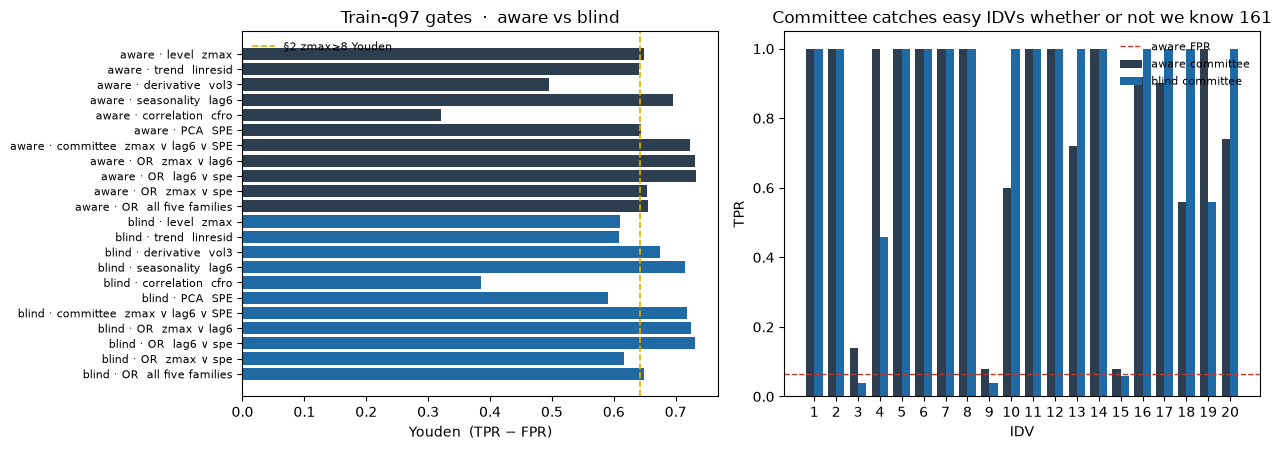

best aware: OR  lag6 ∨ spe  TPR=0.778  FPR=0.046  Youden=0.732
best blind: OR  lag6 ∨ spe  TPR=0.807  FPR=0.076  Youden=0.731
lag6 (slow-loop residual) is the new individual winner; the committee is for when families disagree by IDV.


In [14]:
FAMILY_LABEL = {
    "zmax": "level  zmax",
    "linresid": "trend  linresid",
    "vol3": "derivative  vol3",
    "lag6": "seasonality  lag6",
    "cfro": "correlation  cfro",
    "spe": "PCA  SPE",
}
COMMITTEE = ("zmax", "lag6", "spe")
PAIR_OR = (("zmax", "lag6"), ("lag6", "spe"), ("zmax", "spe"))
ALL_FAM = tuple(FAMILY_LABEL)


def split_clock(clock: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    sub = fam.loc[fam["clock"].eq(clock)]
    return (
        sub.loc[sub["block"].eq("train_normal")],
        sub.loc[sub["block"].eq("test_normal")],
        sub.loc[sub["block"].eq("test_faulty")],
    )


def family_table() -> pd.DataFrame:
    rows = []
    for clock in ("aware", "blind"):
        tr, n, f = split_clock(clock)
        both = pd.concat([n, f], ignore_index=True)
        y = both["csv_status"].astype(str).eq("faulty").to_numpy()
        hard = f["IDV"].astype(int).isin(HARD_IDV).to_numpy()
        thr = {col: float(np.nanquantile(tr[col], THR_Q)) for col in FAMILY_LABEL}
        for col, label in FAMILY_LABEL.items():
            pred_n = n[col] >= thr[col]
            pred_f = f[col] >= thr[col]
            rec = rates_from_pred(y, np.concatenate([pred_n.to_numpy(), pred_f.to_numpy()]))
            rec.update(
                clock=clock,
                method=label,
                thr=thr[col],
                TPR_easy=float(pred_f.to_numpy()[~hard].mean()) if (~hard).any() else np.nan,
                TPR_hard=float(pred_f.to_numpy()[hard].mean()) if hard.any() else np.nan,
            )
            rows.append(rec)
        # committee
        pred_n = np.zeros(len(n), dtype=bool)
        pred_f = np.zeros(len(f), dtype=bool)
        for col in COMMITTEE:
            pred_n |= (n[col] >= thr[col]).to_numpy()
            pred_f |= (f[col] >= thr[col]).to_numpy()
        rec = rates_from_pred(y, np.concatenate([pred_n, pred_f]))
        rec.update(
            clock=clock,
            method="committee  zmax ∨ lag6 ∨ SPE",
            thr=np.nan,
            TPR_easy=float(pred_f[~hard].mean()) if (~hard).any() else np.nan,
            TPR_hard=float(pred_f[hard].mean()) if hard.any() else np.nan,
        )
        rows.append(rec)
        for a, b in PAIR_OR:
            pn = ((n[a] >= thr[a]) | (n[b] >= thr[b])).to_numpy()
            pf = ((f[a] >= thr[a]) | (f[b] >= thr[b])).to_numpy()
            rec = rates_from_pred(y, np.concatenate([pn, pf]))
            rec.update(
                clock=clock,
                method=f"OR  {a} ∨ {b}",
                thr=np.nan,
                TPR_easy=float(pf[~hard].mean()) if (~hard).any() else np.nan,
                TPR_hard=float(pf[hard].mean()) if hard.any() else np.nan,
            )
            rows.append(rec)
        pn = np.zeros(len(n), dtype=bool)
        pf = np.zeros(len(f), dtype=bool)
        for col in ALL_FAM:
            pn |= (n[col] >= thr[col]).to_numpy()
            pf |= (f[col] >= thr[col]).to_numpy()
        rec = rates_from_pred(y, np.concatenate([pn, pf]))
        rec.update(
            clock=clock,
            method="OR  all five families",
            thr=np.nan,
            TPR_easy=float(pf[~hard].mean()) if (~hard).any() else np.nan,
            TPR_hard=float(pf[hard].mean()) if hard.any() else np.nan,
        )
        rows.append(rec)
    out = pd.DataFrame(rows)
    # §2 / v6 controls already in `compare` if that cell ran
    if "compare" in dir() or "compare" in globals():
        ctrl = globals()["compare"]
        z8 = ctrl.loc[ctrl["method"].eq("A prefix_zmax≥8") & ctrl["W"].eq(DEFAULT_W)]
        v6z = ctrl.loc[ctrl["method"].str.contains("zscore_4sd_self k=6", na=False)]
        v5 = ctrl.loc[ctrl["method"].str.contains("v5_combined", na=False)]
        for label, block in (("§2 prefix_zmax≥8  W=220", z8), ("v6 zscore k=6  all t", v6z), ("v6 v5_combined  all t", v5)):
            if block.empty:
                continue
            r = block.iloc[0]
            rows.append(
                {
                    "clock": "control",
                    "method": label,
                    "thr": np.nan,
                    "n_faulty": r.get("n_faulty", np.nan),
                    "n_normal": r.get("n_normal", np.nan),
                    "TPR": r["TPR"],
                    "FPR": r["FPR"],
                    "Youden": r["Youden"],
                    "TP": r.get("TP", np.nan),
                    "FN": r.get("FN", np.nan),
                    "FP": r.get("FP", np.nan),
                    "TN": r.get("TN", np.nan),
                    "TPR_easy": r.get("TPR_easy", np.nan),
                    "TPR_hard": r.get("TPR_hard", np.nan),
                }
            )
        out = pd.DataFrame(rows)
    return out


fam_rates = family_table()
print(f"threshold = train-normal q{THR_Q:.2f}  ·  aware look [{POST_LO}, {AWARE_W}]  ·  blind cal 1–{BLIND_CAL}")
display(
    fam_rates.style.format(
        {"TPR": "{:.3f}", "FPR": "{:.3f}", "Youden": "{:.3f}", "TPR_easy": "{:.3f}", "TPR_hard": "{:.3f}", "thr": "{:.3g}"},
        na_rep="—",
    )
)

# Per-IDV for the two best stories: aware lag6, aware committee, blind lag6
tr_a, n_a, f_a = split_clock("aware")
tr_b, n_b, f_b = split_clock("blind")
thr_a = {c: float(np.nanquantile(tr_a[c], THR_Q)) for c in FAMILY_LABEL}
thr_b = {c: float(np.nanquantile(tr_b[c], THR_Q)) for c in FAMILY_LABEL}


def committee_mask(df: pd.DataFrame, thr: dict) -> np.ndarray:
    m = np.zeros(len(df), dtype=bool)
    for c in COMMITTEE:
        m |= (df[c] >= thr[c]).to_numpy()
    return m


idv_rows = []
for idv, g in f_a.groupby("IDV", sort=True):
    gb = f_b.loc[f_b["IDV"].eq(idv)]
    idv_rows.append(
        {
            "IDV": int(idv),
            "aware_zmax": float((g["zmax"] >= thr_a["zmax"]).mean()),
            "aware_lag6": float((g["lag6"] >= thr_a["lag6"]).mean()),
            "aware_spe": float((g["spe"] >= thr_a["spe"]).mean()),
            "aware_OR": float(committee_mask(g, thr_a).mean()),
            "blind_lag6": float((gb["lag6"] >= thr_b["lag6"]).mean()),
            "blind_OR": float(committee_mask(gb, thr_b).mean()),
        }
    )
# IDV 0 = FPR
idv_rows.append(
    {
        "IDV": 0,
        "aware_zmax": float((n_a["zmax"] >= thr_a["zmax"]).mean()),
        "aware_lag6": float((n_a["lag6"] >= thr_a["lag6"]).mean()),
        "aware_spe": float((n_a["spe"] >= thr_a["spe"]).mean()),
        "aware_OR": float(committee_mask(n_a, thr_a).mean()),
        "blind_lag6": float((n_b["lag6"] >= thr_b["lag6"]).mean()),
        "blind_OR": float(committee_mask(n_b, thr_b).mean()),
    }
)
fam_idv = pd.DataFrame(idv_rows).sort_values("IDV")
print("\nPer IDV  (IDV 0 = FPR). Committee = zmax ∨ lag6 ∨ SPE")
display(fam_idv.style.format("{:.2f}", subset=[c for c in fam_idv.columns if c != "IDV"]))

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))
ax = axes[0]
sub = fam_rates.loc[fam_rates["clock"].isin(["aware", "blind"])].copy()
labels = sub["clock"] + " · " + sub["method"]
y = np.arange(len(sub))
ax.barh(y, sub["Youden"], color=[BLUE if c == "aware" else "#1F6AA5" for c in sub["clock"]])
ax.set_yticks(y, labels, fontsize=8)
ax.axvline(0.642, color=YELLOW, ls="--", lw=1.2, label="§2 zmax≥8 Youden")
ax.set_xlabel("Youden  (TPR − FPR)")
ax.set_title("Train-q97 gates  ·  aware vs blind")
ax.legend(frameon=False, fontsize=8)
ax.invert_yaxis()

ax = axes[1]
fault = fam_idv.loc[fam_idv["IDV"].gt(0)]
x = np.arange(len(fault))
w = 0.38
ax.bar(x - w / 2, fault["aware_OR"], w, color=BLUE, label="aware committee")
ax.bar(x + w / 2, fault["blind_OR"], w, color="#1F6AA5", label="blind committee")
ax.axhline(fam_idv.loc[fam_idv["IDV"].eq(0), "aware_OR"].iloc[0], color=RED, ls="--", lw=1.0, label="aware FPR")
ax.set_xticks(x, fault["IDV"].astype(int))
ax.set_ylim(0, 1.05)
ax.set_xlabel("IDV")
ax.set_ylabel("TPR")
ax.set_title("Committee catches easy IDVs whether or not we know 161")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

best_a = fam_rates.loc[fam_rates["clock"].eq("aware")].sort_values("Youden", ascending=False).iloc[0]
best_b = fam_rates.loc[fam_rates["clock"].eq("blind")].sort_values("Youden", ascending=False).iloc[0]
print(f"best aware: {best_a['method']}  TPR={best_a['TPR']:.3f}  FPR={best_a['FPR']:.3f}  Youden={best_a['Youden']:.3f}")
print(f"best blind: {best_b['method']}  TPR={best_b['TPR']:.3f}  FPR={best_b['FPR']:.3f}  Youden={best_b['Youden']:.3f}")
print("lag6 (slow-loop residual) is the new individual winner; the committee is for when families disagree by IDV.")


## 6. Connect prefix_zmax≥8 with v6 zscore k=6

Run-level OR on the **same 1,500 test keys** (500 normal + 1,000 faulty):

- **A** — `prefix_zmax ≥ 8` on `[161, W]`. Default `W=220`; also `250` and `300`.
- **D** — v6 expanding zscore k=6 on **all** samples (`zscore_4sd_self`, `k=6` in `v6_eval_alarms.csv`).
- **A ∨ D** — call faulty if either fires. TPR/FPR cannot fall below either part.
- **A ∧ D** — both must fire (high-precision check).

This still uses the known 161 gate for A. D does not. The overlap table is the actual question: how many faulty runs does the frozen window catch that expanding k=6 missed, and how many extra healthy runs does the OR spend.


19:55:51  INFO     v6 zscore k=6  test runs=1500  alarm_rate=0.506


Same 1,500 test runs as §3.  A uses onset 161; D watches every sample.


,method,W,n_faulty,n_normal,TPR,FPR,Youden,TPR_easy,TPR_hard,TP,FN,FP,TN
0,A prefix_zmax≥8 W=220,220,1000,500,0.656,0.014,0.642,0.768,0.020,656,344,7,493
1,D zscore_k6 (all t),220,1000,500,0.715,0.088,0.627,0.826,0.087,715,285,44,456
2,A∨D prefix≥8 ∪ zscore_k6 W=220,220,1000,500,0.779,0.098,0.681,0.899,0.100,779,221,49,451
3,A∧D prefix≥8 ∩ zscore_k6 W=220,220,1000,500,0.592,0.004,0.588,0.695,0.007,592,408,2,498
4,A prefix_zmax≥8 W=250,250,1000,500,0.730,0.034,0.696,0.853,0.033,730,270,17,483
5,D zscore_k6 (all t),250,1000,500,0.715,0.088,0.627,0.826,0.087,715,285,44,456
6,A∨D prefix≥8 ∪ zscore_k6 W=250,250,1000,500,0.783,0.112,0.671,0.904,0.100,783,217,56,444
7,A∧D prefix≥8 ∩ zscore_k6 W=250,250,1000,500,0.662,0.010,0.652,0.775,0.020,662,338,5,495
8,A prefix_zmax≥8 W=300,300,1000,500,0.758,0.044,0.714,0.886,0.033,758,242,22,478
9,D zscore_k6 (all t),300,1000,500,0.715,0.088,0.627,0.826,0.087,715,285,44,456



Overlap — extra TP is faulty_prefix_only; extra FP is normal_prefix_only.


,W,faulty_both,faulty_prefix_only,faulty_z6_only,faulty_neither,normal_both,normal_prefix_only,normal_z6_only,normal_neither
0,220,592,64,123,221,2,5,42,451
1,250,662,68,53,217,5,12,39,444
2,300,685,73,30,212,8,14,36,442



Per IDV  (IDV 0 = FPR on 500 test-normal)   W=220


,W,IDV,runs,TPR_prefix,TPR_z6,TPR_union,prefix_only,z6_only
20,220,0,500,0.01,0.09,0.10,0.01,0.08
0,220,1,50,1.00,1.00,1.00,0.00,0.00
1,220,2,50,1.00,1.00,1.00,0.00,0.00
2,220,3,50,0.04,0.10,0.12,0.02,0.08
3,220,4,50,1.00,0.32,1.00,0.68,0.00
4,220,5,50,0.98,1.00,1.00,0.00,0.02
5,220,6,50,1.00,1.00,1.00,0.00,0.00
6,220,7,50,1.00,1.00,1.00,0.00,0.00
7,220,8,50,0.92,1.00,1.00,0.00,0.08
8,220,9,50,0.00,0.10,0.10,0.00,0.10



Per IDV  (IDV 0 = FPR on 500 test-normal)   W=300


,W,IDV,runs,TPR_prefix,TPR_z6,TPR_union,prefix_only,z6_only
20,300,0,500,0.04,0.09,0.12,0.03,0.07
0,300,1,50,1.00,1.00,1.00,0.00,0.00
1,300,2,50,1.00,1.00,1.00,0.00,0.00
2,300,3,50,0.04,0.10,0.12,0.02,0.08
3,300,4,50,1.00,0.32,1.00,0.68,0.00
4,300,5,50,1.00,1.00,1.00,0.00,0.00
5,300,6,50,1.00,1.00,1.00,0.00,0.00
6,300,7,50,1.00,1.00,1.00,0.00,0.00
7,300,8,50,1.00,1.00,1.00,0.00,0.00
8,300,9,50,0.04,0.10,0.10,0.00,0.06


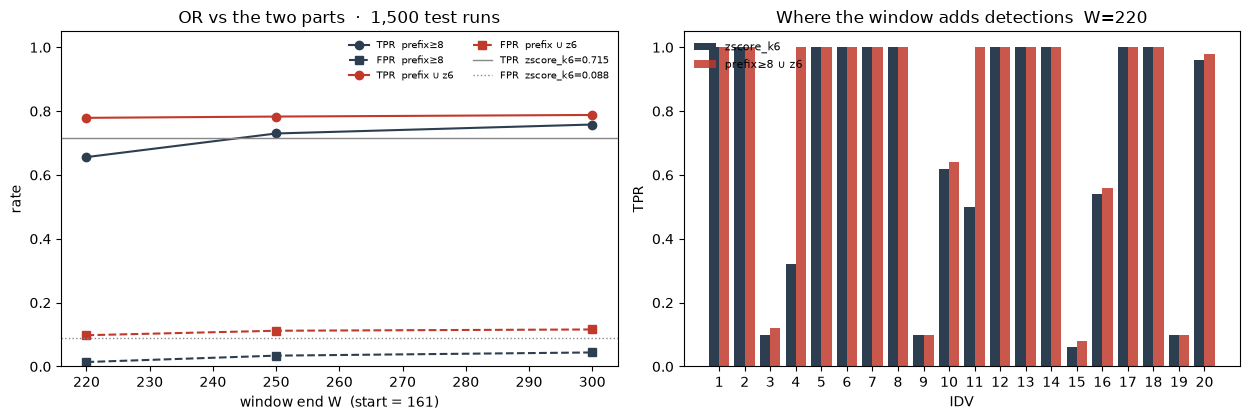

best Youden in this cell: A  prefix_zmax≥8  W=300  TPR=0.758  FPR=0.044  Youden=0.714
zscore_k6:              TPR=0.715  FPR=0.088  Youden=0.627
prefix≥8 W=220:         TPR=0.656  FPR=0.014  Youden=0.642
prefix≥8 ∪ z6  W=220:   TPR=0.779  FPR=0.098  Youden=0.681  ΔYouden vs z6=+0.054
W=220 overlap:  prefix-only TP=64  z6-only TP=123  both TP=592  prefix-only FP=5  z6-only FP=42


In [15]:
UNION_W = (220, 250, 300)
Z6_METHOD = "zscore_4sd_self"
Z6_K = 6.0


def _z6_test_alarms(path: Path) -> pd.DataFrame:
    v6 = pd.read_csv(path, usecols=["method", "k", "source", "IDV", "run", "alarm"])
    out = v6.loc[
        v6["source"].astype(str).eq("test")
        & v6["method"].eq(Z6_METHOD)
        & v6["k"].eq(Z6_K),
        ["IDV", "run", "alarm"],
    ].copy()
    out["IDV"] = out["IDV"].astype(int)
    out["run"] = out["run"].astype(int)
    out["z6"] = out["alarm"].astype(int).eq(1)
    return out[["IDV", "run", "z6"]]


if not V6_ALARMS.exists():
    raise FileNotFoundError(f"need {V6_ALARMS} from v6 §3")

z6_alarms = _z6_test_alarms(V6_ALARMS)
log.info("v6 zscore k=6  test runs=%s  alarm_rate=%.3f", len(z6_alarms), float(z6_alarms["z6"].mean()))

combo_rows = []
overlap_rows = []
idv_rows = []

for w in UNION_W:
    block = scores.loc[scores["W"].eq(w) & scores["block"].isin(["test_normal", "test_faulty"])].copy()
    block["IDV"] = block["IDV"].astype(int)
    block["run"] = block["run"].astype(int)
    block = block.merge(z6_alarms, on=["IDV", "run"], how="left")
    missing = int(block["z6"].isna().sum())
    if missing:
        raise ValueError(f"W={w}: {missing} runs missing from v6 zscore k=6")
    y = block["csv_status"].astype(str).eq("faulty").to_numpy()
    pz = (block["zmax"] >= 8).to_numpy()
    zk = block["z6"].to_numpy(dtype=bool)
    preds = [
        (f"A  prefix_zmax≥8  W={w}", pz),
        ("D  zscore_k6 (all t)", zk),
        (f"A∨D  prefix≥8 ∪ zscore_k6  W={w}", pz | zk),
        (f"A∧D  prefix≥8 ∩ zscore_k6  W={w}", pz & zk),
    ]
    hard = block.loc[block["csv_status"].astype(str).eq("faulty"), "IDV"].isin(HARD_IDV).to_numpy()
    for name, pred in preds:
        rec = rates_from_pred(y, pred)
        pred_f = pred[y]
        rec.update(
            method=name,
            W=w,
            TPR_easy=float(pred_f[~hard].mean()) if (~hard).any() else np.nan,
            TPR_hard=float(pred_f[hard].mean()) if hard.any() else np.nan,
        )
        combo_rows.append(rec)

    nmask = ~y
    overlap_rows.append(
        {
            "W": w,
            "faulty_both": int((pz & zk & y).sum()),
            "faulty_prefix_only": int((pz & ~zk & y).sum()),
            "faulty_z6_only": int((~pz & zk & y).sum()),
            "faulty_neither": int((~pz & ~zk & y).sum()),
            "normal_both": int((pz & zk & nmask).sum()),
            "normal_prefix_only": int((pz & ~zk & nmask).sum()),
            "normal_z6_only": int((~pz & zk & nmask).sum()),
            "normal_neither": int((~pz & ~zk & nmask).sum()),
        }
    )

combo = pd.DataFrame(combo_rows)
overlap = pd.DataFrame(overlap_rows)

print("Same 1,500 test runs as §3.  A uses onset 161; D watches every sample.")
display(
    combo[["method", "W", "n_faulty", "n_normal", "TPR", "FPR", "Youden", "TPR_easy", "TPR_hard", "TP", "FN", "FP", "TN"]]
    .style.format(
        {"TPR": "{:.3f}", "FPR": "{:.3f}", "Youden": "{:.3f}", "TPR_easy": "{:.3f}", "TPR_hard": "{:.3f}", "W": "{:.0f}"},
        na_rep="—",
    )
)

print("\nOverlap — extra TP is faulty_prefix_only; extra FP is normal_prefix_only.")
display(overlap.style.format({"W": "{:.0f}"}))

# Per-IDV complementarity at default W and at the TPR stretch.
for w in (220, 300):
    block = scores.loc[scores["W"].eq(w) & scores["block"].eq("test_faulty")].copy()
    block["IDV"] = block["IDV"].astype(int)
    block["run"] = block["run"].astype(int)
    block = block.merge(z6_alarms, on=["IDV", "run"], how="left")
    nblock = scores.loc[scores["W"].eq(w) & scores["block"].eq("test_normal")].copy()
    nblock["IDV"] = nblock["IDV"].astype(int)
    nblock["run"] = nblock["run"].astype(int)
    nblock = nblock.merge(z6_alarms, on=["IDV", "run"], how="left")
    rows = []
    for idv, g in block.groupby("IDV", sort=True):
        pz = (g["zmax"] >= 8).to_numpy()
        zk = g["z6"].to_numpy(dtype=bool)
        rows.append(
            {
                "W": w,
                "IDV": int(idv),
                "runs": len(g),
                "TPR_prefix": float(pz.mean()),
                "TPR_z6": float(zk.mean()),
                "TPR_union": float((pz | zk).mean()),
                "prefix_only": float((pz & ~zk).mean()),
                "z6_only": float((~pz & zk).mean()),
            }
        )
    pz_n = (nblock["zmax"] >= 8).to_numpy()
    zk_n = nblock["z6"].to_numpy(dtype=bool)
    rows.append(
        {
            "W": w,
            "IDV": 0,
            "runs": len(nblock),
            "TPR_prefix": float(pz_n.mean()),
            "TPR_z6": float(zk_n.mean()),
            "TPR_union": float((pz_n | zk_n).mean()),
            "prefix_only": float((pz_n & ~zk_n).mean()),
            "z6_only": float((~pz_n & zk_n).mean()),
        }
    )
    by = pd.DataFrame(rows).sort_values("IDV")
    print(f"\nPer IDV  (IDV 0 = FPR on 500 test-normal)   W={w}")
    display(
        by.style.format(
            {
                "TPR_prefix": "{:.2f}",
                "TPR_z6": "{:.2f}",
                "TPR_union": "{:.2f}",
                "prefix_only": "{:.2f}",
                "z6_only": "{:.2f}",
            }
        )
    )

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))
ax = axes[0]
or_rows = combo.loc[combo["method"].str.startswith("A∨D")].sort_values("W")
a_rows = combo.loc[combo["method"].str.startswith("A  prefix")].sort_values("W")
d_row = combo.loc[combo["method"].str.startswith("D  zscore")].iloc[0]
ax.plot(a_rows["W"], a_rows["TPR"], "o-", color=BLUE, label="TPR  prefix≥8")
ax.plot(a_rows["W"], a_rows["FPR"], "s--", color=BLUE, label="FPR  prefix≥8")
ax.plot(or_rows["W"], or_rows["TPR"], "o-", color=RED, label="TPR  prefix ∪ z6")
ax.plot(or_rows["W"], or_rows["FPR"], "s--", color=RED, label="FPR  prefix ∪ z6")
ax.axhline(d_row["TPR"], color="#888", lw=1.0, label=f"TPR  zscore_k6={d_row['TPR']:.3f}")
ax.axhline(d_row["FPR"], color="#888", lw=1.0, ls=":", label=f"FPR  zscore_k6={d_row['FPR']:.3f}")
ax.set_xlabel("window end W  (start = 161)")
ax.set_ylabel("rate")
ax.set_ylim(0, 1.05)
ax.set_title("OR vs the two parts  ·  1,500 test runs")
ax.legend(frameon=False, fontsize=7, ncol=2)

ax = axes[1]
w0 = 220
block = scores.loc[scores["W"].eq(w0) & scores["block"].eq("test_faulty")].copy()
block["IDV"] = block["IDV"].astype(int)
block["run"] = block["run"].astype(int)
block = block.merge(z6_alarms, on=["IDV", "run"], how="left")
by_f = (
    block.assign(pz=block["zmax"] >= 8)
    .groupby("IDV", sort=True)
    .apply(lambda g: pd.Series({
        "prefix": float((g["pz"]).mean()),
        "union": float((g["pz"] | g["z6"]).mean()),
        "z6": float(g["z6"].mean()),
    }), include_groups=False)
    .reset_index()
)
x = np.arange(len(by_f))
ax.bar(x - 0.2, by_f["z6"], width=0.4, color=BLUE, label="zscore_k6")
ax.bar(x + 0.2, by_f["union"], width=0.4, color=RED, alpha=0.85, label="prefix≥8 ∪ z6")
ax.set_xticks(x, by_f["IDV"].astype(int))
ax.set_ylim(0, 1.05)
ax.set_xlabel("IDV")
ax.set_ylabel("TPR")
ax.set_title(f"Where the window adds detections  W={w0}")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

best = combo.sort_values("Youden", ascending=False).iloc[0]
z6r = combo.loc[combo["method"].str.startswith("D  zscore")].iloc[0]
a220 = combo.loc[combo["method"].eq("A  prefix_zmax≥8  W=220")].iloc[0]
or220 = combo.loc[combo["method"].eq("A∨D  prefix≥8 ∪ zscore_k6  W=220")].iloc[0]
print(
    f"best Youden in this cell: {best['method']}  "
    f"TPR={best['TPR']:.3f}  FPR={best['FPR']:.3f}  Youden={best['Youden']:.3f}"
)
print(
    f"zscore_k6:              TPR={z6r['TPR']:.3f}  FPR={z6r['FPR']:.3f}  Youden={z6r['Youden']:.3f}"
)
print(
    f"prefix≥8 W=220:         TPR={a220['TPR']:.3f}  FPR={a220['FPR']:.3f}  Youden={a220['Youden']:.3f}"
)
print(
    f"prefix≥8 ∪ z6  W=220:   TPR={or220['TPR']:.3f}  FPR={or220['FPR']:.3f}  Youden={or220['Youden']:.3f}  "
    f"ΔYouden vs z6={or220['Youden'] - z6r['Youden']:+.3f}"
)
ov220 = overlap.loc[overlap["W"].eq(220)].iloc[0]
print(
    f"W=220 overlap:  prefix-only TP={int(ov220['faulty_prefix_only'])}  "
    f"z6-only TP={int(ov220['faulty_z6_only'])}  both TP={int(ov220['faulty_both'])}  "
    f"prefix-only FP={int(ov220['normal_prefix_only'])}  z6-only FP={int(ov220['normal_z6_only'])}"
)


## 7. What the families actually buy

Thresholds = train-normal 97th percentile (not the test set). Eval = 500 test-normal + 1,000 test-faulty.

| clock | best individual | best mutual rule | vs §2 `prefix_zmax≥8` W=220 (Youden 0.642) |
|---|---|---|---|
| **aware** (know 161) | `lag6` TPR 0.715 FPR 0.020 Youden **0.695** | `lag6 ∨ SPE` TPR 0.778 FPR 0.046 Youden **0.732** | +0.09 Youden |
| **blind** (do not know 161) | `lag6` TPR 0.751 FPR 0.036 Youden **0.715** | `lag6 ∨ SPE` TPR 0.807 FPR 0.076 Youden **0.731** | +0.09 Youden |

**Who does what**

- **Seasonality (`lag6`)** is the new individual winner on both clocks. It is the 18-minute composition / analyzer loop: a held-then-jump tag leaves `|x_t − x_{t−6}|` huge while a one-tick zmax still looks modest. That is why it picks up IDV 10 / 16 / 19 that prefix_zmax misses inside `[161, 220]`.
- **Level (`zmax`) and trend (`linresid`)** are almost the same story on both clocks (aware Youden 0.65 / 0.64; blind 0.61 / 0.61). Trend on the blind clock is scored on *sliding* 40-sample windows; a linear forecast of the whole tail from 80 samples is not a detector, it is an extrapolation bomb.
- **PCA SPE** is the complement: IDV 2 is a correlation/combination fault (lag6 TPR 0.30 aware, SPE TPR 1.00). That is why `lag6 ∨ SPE` beats `zmax ∨ lag6` by a hair and beats three-way OR on FPR.
- **Derivative (`vol3`)** is the blind-clock surprise (Youden 0.674): watching the whole run, a volatility burst is a cheap extra TP on IDV 19. Inside the short aware window it is weaker than zmax.
- **Correlation Frobenius** is weak on this plant (Youden ~0.32–0.39). Pairwise `xmeas` RMSE does not beat SPE, which already sees combination faults.
- **OR of all five** is the wrong committee: FPR jumps to 0.15 aware / 0.19 blind. Mutual decision has to be *sparse*. `{lag6, SPE}` is the sparse set.

IDV 3 / 9 / 15 stay near zero on every family. That is not a clock problem and not a missing-family problem.

## 8. EWMA, Mahalanobis, PCA (SPE + T²), Isolation Forest, change-point

Same two clocks and the same train-normal q97 gates as §4. These five are the “textbook” multivariate SPC / anomaly set; the question is whether any of them beats `lag6` or `lag6 ∨ SPE` on this plant.

| method | score | what a high score means |
|---|---|---|
| **EWMA** | max over the look of `\|S_t − μ\| / (σ √(λ/(2−λ)))`, `λ=0.2`, warmup on cal | gradual drift; a slow walk that never makes a 8σ tick |
| **Mahalanobis** | max squared MD of a look tick vs cal, ridge `Σ + 0.01 I` on standardized cal | a tick that is a *wrong combination*, even if every tag is in range |
| **PCA SPE** | max reconstruction error / cal 99th (90% variance) | residual subspace: new variation PCA never saw |
| **PCA T²** | max Hotelling T² / cal 99th, same PCA | in-model: unusual coordinates *along* the normal PCs |
| **Isolation Forest** | max `−score_samples` on the look; tree fitted only on this run’s cal | nonlinear / isolation in 52-d; 80–160 cal rows is a weak forest on purpose (causal, no other runs) |
| **CUSUM** | two-sided CUSUM of per-sensor z vs cal, allowance 1.0; score = peak | *when* the mean moved; accumulates a persistent shift |

Aware: cal `1–160`, look `[161, 220]`. Blind: cal `1–80`, look = the rest of the run.

In [16]:
from sklearn.ensemble import IsolationForest

EWMA_LAM = 0.2
CUSUM_K = 1.0
MAHA_RIDGE = 1e-2
IF_TREES = 40
EXTRA_KEYS = ("ewma", "maha", "spe", "t2", "iforest", "cusum")


def _ewma_max(pre: np.ndarray, look: np.ndarray, lam: float = EWMA_LAM) -> float:
    mu = pre.mean(axis=0)
    sd = np.maximum(pre.std(axis=0, ddof=1), 1e-12)
    scale = np.maximum(sd * np.sqrt(lam / (2.0 - lam)), 1e-12)
    ewma = mu.copy()
    a, b = 1.0 - lam, lam
    for row in pre:
        ewma *= a
        ewma += b * row
    best = 0.0
    for row in look:
        ewma *= a
        ewma += b * row
        best = max(best, float(np.max(np.abs(ewma - mu) / scale)))
    return best


def _ridge_maha(pre: np.ndarray, look: np.ndarray, ridge: float = MAHA_RIDGE) -> float:
    mu = pre.mean(axis=0)
    sd = np.maximum(pre.std(axis=0, ddof=1), 1e-12)
    zpre = (pre - mu) / sd
    zlook = (look - mu) / sd
    n, p = zpre.shape
    cov = (zpre.T @ zpre) / max(n - 1, 1)
    cov.flat[:: p + 1] += ridge
    try:
        prec = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        prec = np.linalg.pinv(cov)
    md2 = np.einsum("ij,jk,ik->i", zlook, prec, zlook)
    return float(np.max(md2))


def _pca_spe_t2(pre: np.ndarray, look: np.ndarray) -> tuple[float, float]:
    sc = StandardScaler()
    zpre = sc.fit_transform(pre)
    pca = PCA(n_components=0.90, svd_solver="full")
    pca.fit(zpre)
    ev = np.maximum(pca.explained_variance_, 1e-12)

    def pack(Xp: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        z = sc.transform(Xp)
        t = pca.transform(z)
        rec = pca.inverse_transform(t)
        spe = np.sum((z - rec) ** 2, axis=1)
        t2 = np.sum((t / np.sqrt(ev)) ** 2, axis=1)
        return spe, t2

    spe_pre, t2_pre = pack(pre)
    spe_look, t2_look = pack(look)
    spe_r = float(spe_look.max() / max(float(np.quantile(spe_pre, 0.99)), 1e-12))
    t2_r = float(t2_look.max() / max(float(np.quantile(t2_pre, 0.99)), 1e-12))
    return spe_r, t2_r


def _iforest_max(pre: np.ndarray, look: np.ndarray) -> float:
    sc = StandardScaler()
    zpre = sc.fit_transform(pre)
    zlook = sc.transform(look)
    iso = IsolationForest(
        n_estimators=IF_TREES,
        max_samples=min(64, len(pre)),
        n_jobs=1,
        random_state=0,
    )
    iso.fit(zpre)
    return float((-iso.score_samples(zlook)).max())


def _cusum_peak(pre: np.ndarray, look: np.ndarray, k: float = CUSUM_K) -> float:
    mu = pre.mean(axis=0)
    sd = np.maximum(pre.std(axis=0, ddof=1), 1e-12)
    z = (look - mu) / sd
    gp = np.zeros(z.shape[1], dtype=np.float64)
    gn = np.zeros(z.shape[1], dtype=np.float64)
    peak = 0.0
    for row in z:
        gp = np.maximum(0.0, gp + row - k)
        gn = np.maximum(0.0, gn - row - k)
        peak = max(peak, float(gp.max()), float(gn.max()))
    return peak


def extra_block(pre: np.ndarray, look: np.ndarray) -> dict:
    if len(pre) < 40 or len(look) < 8:
        return {k: np.nan for k in EXTRA_KEYS}
    spe, t2 = _pca_spe_t2(pre, look)
    return {
        "ewma": _ewma_max(pre, look),
        "maha": _ridge_maha(pre, look),
        "spe": spe,
        "t2": t2,
        "iforest": _iforest_max(pre, look),
        "cusum": _cusum_peak(pre, look),
    }


def extra_aware(X: np.ndarray, s: np.ndarray, w: int = AWARE_W) -> dict:
    return extra_block(_window(X, s, PRE_LO, PRE_HI), _window(X, s, POST_LO, w))


def extra_blind(X: np.ndarray, s: np.ndarray, cal_hi: int = BLIND_CAL) -> dict:
    return extra_block(_window(X, s, 1, cal_hi), X[s > cal_hi])


def load_or_score_extra() -> pd.DataFrame:
    if EXTRA_CACHE.exists():
        out = pd.read_csv(EXTRA_CACHE)
        log.info("extra cache %s  rows=%s", EXTRA_CACHE.name, f"{len(out):,}")
        return out
    rows = []
    t0 = time.time()
    blocks = (("test_normal", test_normal), ("test_faulty", test_faulty), ("train_normal", train_normal))
    for block, df in blocks:
        n = 0
        for src, fn, rn, status, X, s in _iter_runs(df):
            meta = {"block": block, "source": src, "IDV": fn, "run": rn, "csv_status": status}
            rows.append({**meta, "clock": "aware", **extra_aware(X, s)})
            rows.append({**meta, "clock": "blind", **extra_blind(X, s)})
            n += 1
        log.info("extra       %s  runs=%s  %.1fs", block, n, time.time() - t0)
    out = pd.DataFrame(rows)
    out.to_csv(EXTRA_CACHE, index=False)
    log.info("extra write %s  rows=%s", EXTRA_CACHE.name, f"{len(out):,}")
    return out


extra = load_or_score_extra()
print(extra.groupby(["clock", "block"]).size())
display(extra.head())


19:55:51  INFO     extra cache v7_extra_scores.csv  rows=4,000


clock  block       
aware  test_faulty     1000
       test_normal      500
       train_normal     500
blind  test_faulty     1000
       test_normal      500
       train_normal     500
dtype: int64


,block,source,IDV,run,csv_status,clock,ewma,maha,spe,t2,iforest,cusum
0,test_normal,test,0,1,normal,aware,6.457429,136.021164,2.205222,1.060788,0.553150,33.280624
1,test_normal,test,0,1,normal,blind,14.836561,546.968375,7.107331,1.676799,0.600991,287.286791
2,test_normal,test,0,2,normal,aware,10.910967,132.756844,2.960134,1.431189,0.531282,47.688462
3,test_normal,test,0,2,normal,blind,31.410893,1866.956615,21.526256,3.235290,0.591439,614.135882
4,test_normal,test,0,3,normal,aware,8.310551,170.781693,2.485114,1.226627,0.541491,40.536091


## 9. Extra methods vs §4 families — TPR / FPR

Gates = train-normal q97, per clock. The table puts the new five next to `zmax`, `lag6`, and `lag6 ∨ SPE` so the difference is a Youden gap, not a story. Pairwise OR with `lag6` answers “does this mechanism add detections the slow-loop residual already missed?”

threshold = train-normal q0.97  ·  aware look [161, 220]  ·  blind cal 1–80


,clock,method,thr,TPR,FPR,Youden,TPR_easy,TPR_hard,TP,FN,FP,TN
0,aware,EWMA gradual drift,20.1,0.596,0.026,0.570,0.694,0.040,596,404,13,487
1,aware,Mahalanobis combinations,312,0.766,0.036,0.730,0.895,0.033,766,234,18,482
2,aware,PCA SPE residual,5.76,0.674,0.030,0.644,0.787,0.033,674,326,15,485
3,aware,PCA T² in-model,2.35,0.651,0.044,0.607,0.754,0.067,651,349,22,478
4,aware,IsolationForest nonlinear,0.598,0.402,0.030,0.372,0.471,0.013,402,598,15,485
5,aware,CUSUM change-point,202,0.465,0.020,0.445,0.544,0.020,465,535,10,490
6,aware,level zmax (§4),7.31,0.676,0.028,0.648,0.788,0.040,676,324,14,486
7,aware,seasonality lag6 (§4),2.98,0.715,0.020,0.695,0.834,0.040,715,285,10,490
8,aware,PCA SPE (§4 cache),5.76,0.674,0.030,0.644,0.787,0.033,674,326,15,485
9,aware,§4 lag6 ∨ SPE,—,0.778,0.046,0.732,0.902,0.073,778,222,23,477



Per IDV  (IDV 0 = FPR)


,IDV,ewma,maha,spe,t2,iforest,cusum,lag6
20,0,0.03,0.04,0.03,0.04,0.03,0.02,0.02
0,1,1.00,1.00,1.00,1.00,1.00,1.00,1.00
1,2,1.00,1.00,1.00,1.00,0.78,1.00,0.30
2,3,0.06,0.06,0.06,0.10,0.00,0.04,0.06
3,4,1.00,0.84,0.82,1.00,0.08,1.00,1.00
4,5,1.00,1.00,1.00,1.00,1.00,1.00,1.00
5,6,1.00,1.00,1.00,1.00,1.00,1.00,1.00
6,7,1.00,1.00,1.00,1.00,1.00,1.00,1.00
7,8,0.90,0.96,0.98,1.00,0.88,0.66,1.00
8,9,0.04,0.02,0.02,0.06,0.02,0.00,0.02


aware above · blind below


,IDV,ewma,maha,spe,t2,iforest,cusum,lag6
41,0,0.06,0.04,0.05,0.06,0.07,0.11,0.04
21,1,1.00,1.00,1.00,1.00,1.00,1.00,1.00
22,2,1.00,1.00,1.00,1.00,0.98,1.00,0.12
23,3,0.02,0.04,0.04,0.02,0.08,0.04,0.00
24,4,0.06,0.08,0.08,0.06,0.06,1.00,0.42
25,5,0.90,0.90,0.88,0.96,0.98,0.54,0.98
26,6,1.00,1.00,1.00,1.00,1.00,1.00,1.00
27,7,1.00,1.00,1.00,1.00,1.00,1.00,1.00
28,8,1.00,1.00,1.00,1.00,1.00,1.00,1.00
29,9,0.00,0.02,0.04,0.02,0.02,0.10,0.00


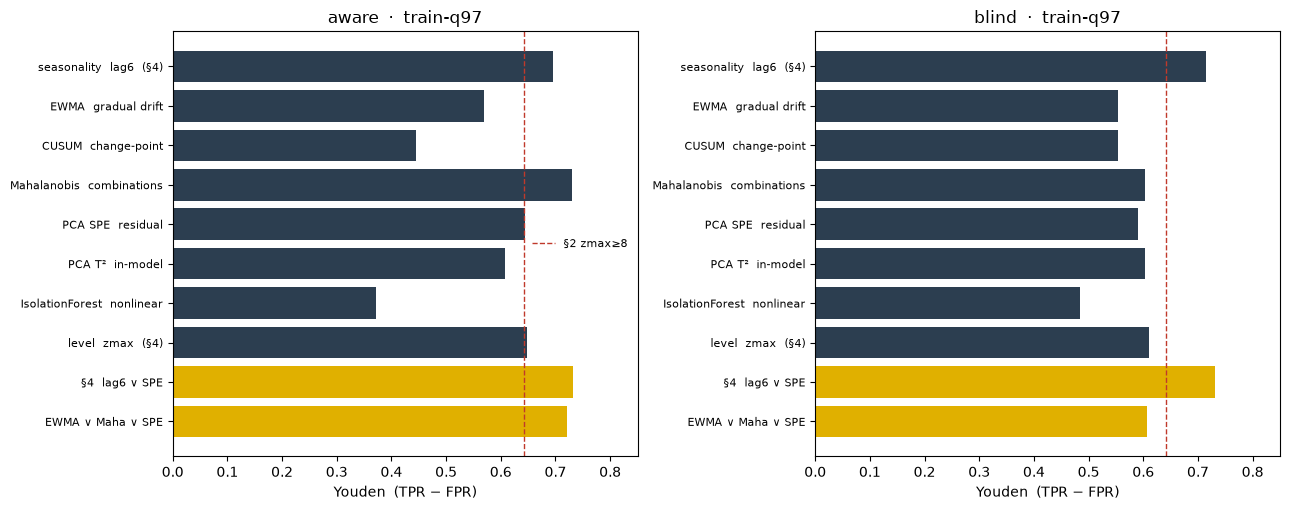

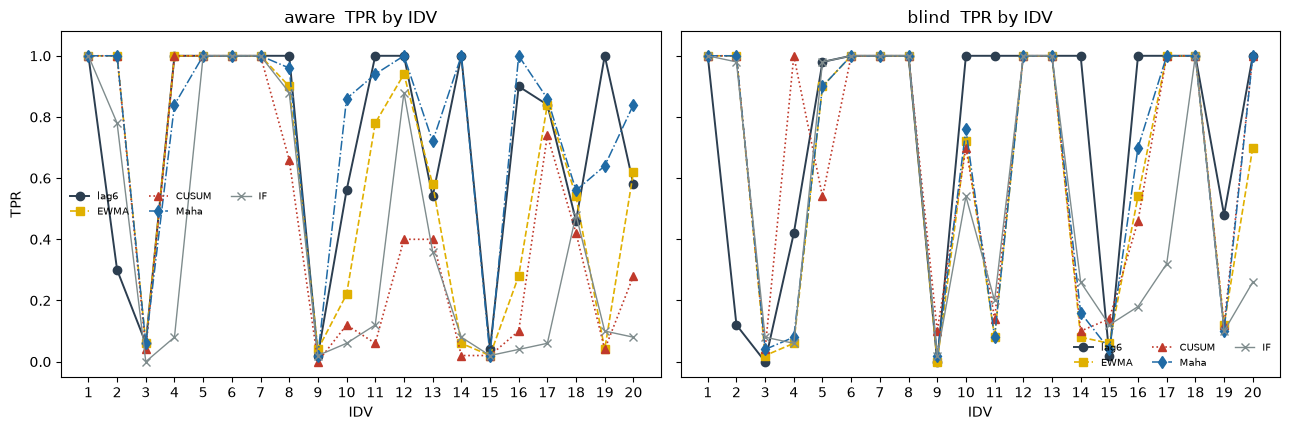

best aware: lag6 ∨ Maha  TPR=0.802  FPR=0.050  Youden=0.752
best blind: lag6 ∨ Maha  TPR=0.804  FPR=0.064  Youden=0.740


In [17]:
EXTRA_LABEL = {
    "ewma": "EWMA  gradual drift",
    "maha": "Mahalanobis  combinations",
    "spe": "PCA SPE  residual",
    "t2": "PCA T²  in-model",
    "iforest": "IsolationForest  nonlinear",
    "cusum": "CUSUM  change-point",
}
REF_FROM_FAM = {
    "zmax": "level  zmax  (§4)",
    "lag6": "seasonality  lag6  (§4)",
    "spe": "PCA SPE  (§4 cache)",
}


def _split(df: pd.DataFrame, clock: str):
    sub = df.loc[df["clock"].eq(clock)]
    return (
        sub.loc[sub["block"].eq("train_normal")],
        sub.loc[sub["block"].eq("test_normal")],
        sub.loc[sub["block"].eq("test_faulty")],
    )


def _rate_row(clock, method, thr, n, f, col_or_mask_n, col_or_mask_f, hard):
    if isinstance(col_or_mask_n, str):
        pn = (n[col_or_mask_n] >= thr).to_numpy()
        pf = (f[col_or_mask_f] >= thr).to_numpy()
    else:
        pn, pf = col_or_mask_n, col_or_mask_f
    y = np.concatenate([np.zeros(len(n), dtype=bool), np.ones(len(f), dtype=bool)])
    rec = rates_from_pred(y, np.concatenate([pn, pf]))
    rec.update(
        clock=clock,
        method=method,
        thr=thr if np.isscalar(thr) else np.nan,
        TPR_easy=float(pf[~hard].mean()) if (~hard).any() else np.nan,
        TPR_hard=float(pf[hard].mean()) if hard.any() else np.nan,
    )
    return rec


extra_rows = []
for clock in ("aware", "blind"):
    tr_e, n_e, f_e = _split(extra, clock)
    tr_f, n_f, f_f = split_clock(clock)
    hard = f_e["IDV"].astype(int).isin(HARD_IDV).to_numpy()
    thr_e = {c: float(np.nanquantile(tr_e[c], THR_Q)) for c in EXTRA_LABEL}
    thr_f = {c: float(np.nanquantile(tr_f[c], THR_Q)) for c in REF_FROM_FAM}

    for c, lab in EXTRA_LABEL.items():
        extra_rows.append(_rate_row(clock, lab, thr_e[c], n_e, f_e, c, c, hard))
    for c, lab in REF_FROM_FAM.items():
        extra_rows.append(_rate_row(clock, lab, thr_f[c], n_f, f_f, c, c, hard))

    # lag6 ∨ SPE from §4
    pn = ((n_f["lag6"] >= thr_f["lag6"]) | (n_f["spe"] >= thr_f["spe"])).to_numpy()
    pf = ((f_f["lag6"] >= thr_f["lag6"]) | (f_f["spe"] >= thr_f["spe"])).to_numpy()
    extra_rows.append(_rate_row(clock, "§4  lag6 ∨ SPE", np.nan, n_f, f_f, pn, pf, hard))

    # each extra method OR lag6 (does it add anything?)
    for c, lab in (("ewma", "EWMA"), ("maha", "Maha"), ("t2", "T²"), ("iforest", "IF"), ("cusum", "CUSUM")):
        pn = ((n_f["lag6"] >= thr_f["lag6"]) | (n_e[c] >= thr_e[c])).to_numpy()
        pf = ((f_f["lag6"] >= thr_f["lag6"]) | (f_e[c] >= thr_e[c])).to_numpy()
        extra_rows.append(_rate_row(clock, f"lag6 ∨ {lab}", np.nan, n_f, f_f, pn, pf, hard))

    # textbook committee: EWMA ∨ Maha ∨ SPE
    pn = ((n_e["ewma"] >= thr_e["ewma"]) | (n_e["maha"] >= thr_e["maha"]) | (n_e["spe"] >= thr_e["spe"])).to_numpy()
    pf = ((f_e["ewma"] >= thr_e["ewma"]) | (f_e["maha"] >= thr_e["maha"]) | (f_e["spe"] >= thr_e["spe"])).to_numpy()
    extra_rows.append(_rate_row(clock, "EWMA ∨ Maha ∨ SPE", np.nan, n_e, f_e, pn, pf, hard))

extra_rates = pd.DataFrame(extra_rows)
print(f"threshold = train-normal q{THR_Q:.2f}  ·  aware look [{POST_LO}, {AWARE_W}]  ·  blind cal 1–{BLIND_CAL}")
show_cols = ["clock", "method", "thr", "TPR", "FPR", "Youden", "TPR_easy", "TPR_hard", "TP", "FN", "FP", "TN"]
display(
    extra_rates[show_cols].style.format(
        {"TPR": "{:.3f}", "FPR": "{:.3f}", "Youden": "{:.3f}", "TPR_easy": "{:.3f}", "TPR_hard": "{:.3f}", "thr": "{:.3g}"},
        na_rep="—",
    )
)

# Per-IDV: extra methods + lag6
idv_rows = []
for clock, df_e, df_fam in (("aware", extra, fam), ("blind", extra, fam)):
    tr_e, n_e, f_e = _split(df_e, clock)
    tr_f, n_f, f_f = _split(df_fam, clock)
    thr_e = {c: float(np.nanquantile(tr_e[c], THR_Q)) for c in EXTRA_LABEL}
    thr_lag = float(np.nanquantile(tr_f["lag6"], THR_Q))
    for idv, g in f_e.groupby("IDV", sort=True):
        gf = f_f.loc[f_f["IDV"].eq(idv)]
        rec = {"clock": clock, "IDV": int(idv)}
        for c in EXTRA_LABEL:
            rec[c] = float((g[c] >= thr_e[c]).mean())
        rec["lag6"] = float((gf["lag6"] >= thr_lag).mean())
        idv_rows.append(rec)
    rec = {"clock": clock, "IDV": 0}
    for c in EXTRA_LABEL:
        rec[c] = float((n_e[c] >= thr_e[c]).mean())
    rec["lag6"] = float((n_f["lag6"] >= thr_lag).mean())
    idv_rows.append(rec)
extra_idv = pd.DataFrame(idv_rows).sort_values(["clock", "IDV"])
print("\nPer IDV  (IDV 0 = FPR)")
display(extra_idv.loc[extra_idv["clock"].eq("aware")].drop(columns="clock").style.format("{:.2f}", subset=[c for c in extra_idv.columns if c not in ("clock", "IDV")]))
print("aware above · blind below")
display(extra_idv.loc[extra_idv["clock"].eq("blind")].drop(columns="clock").style.format("{:.2f}", subset=[c for c in extra_idv.columns if c not in ("clock", "IDV")]))

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))
order = [
    "seasonality  lag6  (§4)",
    "EWMA  gradual drift",
    "CUSUM  change-point",
    "Mahalanobis  combinations",
    "PCA SPE  residual",
    "PCA T²  in-model",
    "IsolationForest  nonlinear",
    "level  zmax  (§4)",
    "§4  lag6 ∨ SPE",
    "EWMA ∨ Maha ∨ SPE",
]
for ax, clock in zip(axes, ("aware", "blind")):
    sub = extra_rates.loc[extra_rates["clock"].eq(clock) & extra_rates["method"].isin(order)].copy()
    sub["ord"] = sub["method"].map({m: i for i, m in enumerate(order)})
    sub = sub.sort_values("ord")
    colors = [YELLOW if "∨" in m or "§4  lag6" in m else BLUE for m in sub["method"]]
    y = np.arange(len(sub))
    ax.barh(y, sub["Youden"], color=colors)
    ax.set_yticks(y, sub["method"], fontsize=8)
    ax.axvline(0.642, color=RED, ls="--", lw=1.0, label="§2 zmax≥8")
    ax.set_xlabel("Youden  (TPR − FPR)")
    ax.set_title(f"{clock}  ·  train-q97")
    ax.invert_yaxis()
    ax.set_xlim(0, 0.85)
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), sharey=True)
for ax, clock in zip(axes, ("aware", "blind")):
    block = extra_idv.loc[extra_idv["clock"].eq(clock) & extra_idv["IDV"].gt(0)]
    x = np.arange(len(block))
    ax.plot(x, block["lag6"], "o-", color=BLUE, lw=1.4, label="lag6")
    ax.plot(x, block["ewma"], "s--", color=YELLOW, lw=1.2, label="EWMA")
    ax.plot(x, block["cusum"], "^:", color=RED, lw=1.2, label="CUSUM")
    ax.plot(x, block["maha"], "d-.", color="#1F6AA5", lw=1.1, label="Maha")
    ax.plot(x, block["iforest"], "x-", color="#7F8C8D", lw=1.0, label="IF")
    ax.set_xticks(x, block["IDV"].astype(int))
    ax.set_ylim(-0.05, 1.08)
    ax.set_xlabel("IDV")
    ax.set_title(f"{clock}  TPR by IDV")
    ax.legend(frameon=False, fontsize=7, ncol=3)
axes[0].set_ylabel("TPR")
fig.tight_layout()
plt.show()

for clock in ("aware", "blind"):
    sub = extra_rates.loc[extra_rates["clock"].eq(clock)].sort_values("Youden", ascending=False)
    b = sub.iloc[0]
    print(f"best {clock}: {b['method']}  TPR={b['TPR']:.3f}  FPR={b['FPR']:.3f}  Youden={b['Youden']:.3f}")


## 10. What the textbook five actually change

Train-q97, 500 test-normal + 1,000 test-faulty.

| | aware Youden | blind Youden | vs `lag6` |
|---|---:|---:|---|
| **Mahalanobis** | **0.730** (TPR 0.766 FPR 0.036) | 0.604 | **beats lag6 on the aware clock**; the missing piece on IDV 2 / 10 / 14 / 16 |
| PCA SPE | 0.644 | 0.591 | same as §4; residual subspace |
| PCA T² | 0.607 | 0.603 | in-model cousin of Maha; strictly weaker than ridge MD |
| EWMA | 0.570 | 0.554 | gradual drift only; dies on IDV 14 (stiction is not a slow walk) |
| CUSUM | 0.445 | 0.553 | high-precision on the short window (FPR 0.020) but low TPR; blind FPR 0.114 from a long accumulate |
| Isolation Forest | 0.372 | 0.485 | 80–160 cal rows × 52 tags is not enough forest; nonlinear capacity does not show up |

**Best mutual rule is now `lag6 ∨ Mahalanobis`**, not `lag6 ∨ SPE`:

- aware: TPR 0.802 FPR 0.050 Youden **0.752**  (was 0.732)
- blind: TPR 0.804 FPR 0.064 Youden **0.740**  (was 0.731)

Mahalanobis is SPE’s job done in the original coordinates with a ridge. It is the “strange combination” detector; lag6 is the “slow loop broke” detector. EWMA / CUSUM / Isolation Forest do not add Youden once those two are on. IDV 3 / 9 / 15 still do not move.